In [1]:
!pip install pycountry

In [1]:
# importing of all libraries. mounting the google drive
# to retreive files and changing the working directory


# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import scipy.stats as st
import missingno as msno
import pycountry
import plotly.express as px
import geopandas as gpd
import os


pd.set_option('display.max_columns', None)

# Replace 'MyDataFolder' with the actual path to your data folder in Google Drive
# Use raw string (r prefix) or double backslashes or forward slashes for Windows paths
drive_data_path = r'C:\Users\shahu\OPEN CLASSROOMS\PROJET 2\data'  # Using raw string
# Alternative options:
# drive_data_path = 'C:\\Users\\shahu\\OPEN CLASSROOMS\\PROJET 2\\data'  # Double backslashes
# drive_data_path = 'C:/Users/shahu/OPEN CLASSROOMS/PROJET 2/data'  # Forward slashes

# Change the current working directory
os.chdir(r'C:\Users\shahu\OPEN CLASSROOMS\PROJET 2\data')

# Project Context

We are working with an EdTech startup called academy, which provides online learning content aimed at high school and university students.

Mark, the manager, has called a meeting to discuss the company’s international expansion strategy. As part of this process, he has requested an exploratory data analysis (EDA) to support decision-making.

## Mission Objectives



*   Investigate whether World Bank education datasets can provide valuable insights for guiding expansion decisions.
*   Identify countries with strong potential demand for academy’s online learning services.
*   Explore how this potential may evolve over time, using available education and demographic indicators.



## Expected Outcome

By the end of this analysis, we aim to determine whether these datasets can effectively guide academy in selecting target countries for its international expansion.

# Processed Data


1.   Indicator_data
2.   Country_indicator



# Indicator_data


""
### Description

The `EdStatsSeries` table contains data about indicators, with the following variables:
- `Series Code`: Unique identifier for each indicator series.
- `Topic`: Category or theme of the indicator (to be dropped).
- `Indicator Name`: Name/description of the indicator.

### Assessment

For further analysis, only `Series Code` and `Indicator Name` are relevant.
The `Topic` variable will be dropped as other variables.
"""


In [2]:
indicator_data = pd.read_csv('EdStatsSeries.csv')
indicator_data.head()


FileNotFoundError: [Errno 2] No such file or directory: 'EdStatsSeries.csv'

In [ ]:
indicator_data.shape

In [5]:
print(indicator_data.duplicated().sum())

0


In [6]:
indicator_data.drop_duplicates().reset_index()

,index,Series Code,Topic,Indicator Name,Short definition,Long definition,Unit of measure,Periodicity,Base Period,Other notes,Aggregation method,Limitations and exceptions,Notes from original source,General comments,Source,Statistical concept and methodology,Development relevance,Related source links,Other web links,Related indicators,License Type,Unnamed: 20
0,0,BAR.NOED.1519.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15-19 with...,Percentage of female population age 15-19 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,BAR.NOED.1519.ZS,Attainment,Barro-Lee: Percentage of population age 15-19 ...,Percentage of population age 15-19 with no edu...,Percentage of population age 15-19 with no edu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,BAR.NOED.15UP.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 15+ with n...,Percentage of female population age 15+ with n...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,BAR.NOED.15UP.ZS,Attainment,Barro-Lee: Percentage of population age 15+ wi...,Percentage of population age 15+ with no educa...,Percentage of population age 15+ with no educa...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,BAR.NOED.2024.FE.ZS,Attainment,Barro-Lee: Percentage of female population age...,Percentage of female population age 20-24 with...,Percentage of female population age 20-24 with...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Robert J. Barro and Jong-Wha Lee: http://www.b...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3660,3660,UIS.XUNIT.USCONST.3.FSGOV,Expenditures,Government expenditure per upper secondary stu...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3661,3661,UIS.XUNIT.USCONST.4.FSGOV,Expenditures,Government expenditure per post-secondary non-...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3662,3662,UIS.XUNIT.USCONST.56.FSGOV,Expenditures,Government expenditure per tertiary student (c...,NaN,"Average total (current, capital and transfers)...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3663,3663,XGDP.23.FSGOV.FDINSTADM.FFD,Expenditures,Government expenditure in secondary institutio...,"Total general (local, regional and central) go...","Total general (local, regional and central) go...",NaN,NaN,NaN,Secondary,NaN,NaN,NaN,NaN,UNESCO Institute for Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
indicator_data.dtypes

Series Code                             object
Topic                                   object
Indicator Name                          object
Short definition                        object
Long definition                         object
Unit of measure                        float64
Periodicity                             object
Base Period                             object
Other notes                             object
Aggregation method                      object
Limitations and exceptions              object
Notes from original source             float64
General comments                        object
Source                                  object
Statistical concept and methodology     object
Development relevance                   object
Related source links                    object
Other web links                        float64
Related indicators                     float64
License Type                           float64
Unnamed: 20                            float64
dtype: object

In [8]:
missing_data = indicator_data.isna().mean().sort_values(ascending=False)
print(missing_data)

Unnamed: 20                            1.000000
Notes from original source             1.000000
License Type                           1.000000
Related indicators                     1.000000
Other web links                        1.000000
Unit of measure                        1.000000
Development relevance                  0.999181
General comments                       0.996180
Limitations and exceptions             0.996180
Statistical concept and methodology    0.993724
Aggregation method                     0.987176
Periodicity                            0.972988
Related source links                   0.941337
Base Period                            0.914325
Other notes                            0.849386
Short definition                       0.411733
Topic                                  0.000000
Source                                 0.000000
Long definition                        0.000000
Indicator Name                         0.000000
Series Code                            0

In [9]:
indicator_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3665 entries, 0 to 3664
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Series Code                          3665 non-null   object 
 1   Topic                                3665 non-null   object 
 2   Indicator Name                       3665 non-null   object 
 3   Short definition                     2156 non-null   object 
 4   Long definition                      3665 non-null   object 
 5   Unit of measure                      0 non-null      float64
 6   Periodicity                          99 non-null     object 
 7   Base Period                          314 non-null    object 
 8   Other notes                          552 non-null    object 
 9   Aggregation method                   47 non-null     object 
 10  Limitations and exceptions           14 non-null     object 
 11  Notes from original source    

In [10]:
indicator_data.describe()

,Unit of measure,Notes from original source,Other web links,Related indicators,License Type,Unnamed: 20
count,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# deleting columns with missing values and unnecessary columns through judgement

columns_tokeep = ['Series Code','Indicator Name']
indicator_data = indicator_data[columns_tokeep]
indicator_data.head()

,Series Code,Indicator Name
0,BAR.NOED.1519.FE.ZS,Barro-Lee: Percentage of female population age...
1,BAR.NOED.1519.ZS,Barro-Lee: Percentage of population age 15-19 ...
2,BAR.NOED.15UP.FE.ZS,Barro-Lee: Percentage of female population age...
3,BAR.NOED.15UP.ZS,Barro-Lee: Percentage of population age 15+ wi...
4,BAR.NOED.2024.FE.ZS,Barro-Lee: Percentage of female population age...


### Processing

In this step, **only the chosen indicators of interest** will be selected from the `indicators_values` dataframe. This filtering ensures that the analysis focuses exclusively on the **relevant indicators**, excluding any unnecessary or unrelated data.This is performed by manually reviewing the excel files with the topics and indicators and selecting indicators of interest in function of topics and indicator names.

In [12]:
# Read the Excel file
indicator_list = pd.read_excel("Indicators.xlsx")

# Make sure to extract the list of Series Codes
codes_to_keep = indicator_list["Series Code"].unique().tolist()

# Filter indicator_data based on the codes
indicator_data = indicator_data[indicator_data["Series Code"].isin(codes_to_keep)]

print(indicator_data)

                Series Code                                     Indicator Name
610          IT.CMP.PCMP.P2                Personal computers (per 100 people)
611          IT.NET.USER.P2                    Internet users (per 100 people)
1658         NY.GDP.MKTP.CD                                  GDP (current US$)
1659         NY.GDP.MKTP.KD                            GDP (constant 2010 US$)
1662         NY.GDP.PCAP.CD                       GDP per capita (current US$)
1930      PRJ.POP.1519.3.MF  Projection: Population age 15-19 in thousands ...
1933      PRJ.POP.1519.4.MF  Projection: Population age 15-19 in thousands ...
2298         SE.SEC.ENRL.GC  Enrolment in secondary general, both sexes (nu...
2307            SE.SEC.ENRR   Gross enrolment ratio, secondary, both sexes (%)
2332            SE.TER.ENRL  Enrolment in tertiary education, all programme...
2376      SE.XPD.SECO.PC.ZS  Government expenditure per secondary student a...
2378      SE.XPD.TERT.PC.ZS  Government expenditure 

# Country_indicator

""
### Description
This table contains records of indicator implementations by country, with the following columns:
- **`country_code`**: Unique identifier for each country.
- **`series_code`**: Unique identifier for each indicator (matches the `series_code` in the `Indicator Data` table).
- **`year`**: Year the indicator was implemented in the country.
- **`description`**: Likely a note or context about the implementation providing the reliability of the source (e.g., details or conditions).


### Assessment



- The table appears to track **which indicators (`series_code`) have been implemented in each country (`country_code`) and the corresponding year**.
- At this stage, this table does not seem immediately useful for the current analysis, as the focus is on indicator metadata rather than country-specific implementation timelines.
""



In [13]:
country_indicator= pd.read_csv('EdStatsFootNote.csv')
country_indicator.head()


,CountryCode,SeriesCode,Year,DESCRIPTION,Unnamed: 4
0,ABW,SE.PRE.ENRL.FE,YR2001,Country estimation.,NaN
1,ABW,SE.TER.TCHR.FE,YR2005,Country estimation.,NaN
2,ABW,SE.PRE.TCHR.FE,YR2000,Country estimation.,NaN
3,ABW,SE.SEC.ENRL.GC,YR2004,Country estimation.,NaN
4,ABW,SE.PRE.TCHR,YR2006,Country estimation.,NaN


In [14]:
country_indicator.shape

(643638, 5)

In [15]:
missing_values = country_indicator.isna().mean().sort_values(ascending=False)
print(missing_values)

Unnamed: 4     1.0
CountryCode    0.0
SeriesCode     0.0
Year           0.0
DESCRIPTION    0.0
dtype: float64


In [16]:
country_indicator.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 643638 entries, 0 to 643637
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CountryCode  643638 non-null  object 
 1   SeriesCode   643638 non-null  object 
 2   Year         643638 non-null  object 
 3   DESCRIPTION  643638 non-null  object 
 4   Unnamed: 4   0 non-null       float64
dtypes: float64(1), object(4)
memory usage: 24.6+ MB


In [17]:
country_indicator.describe()

,Unnamed: 4
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


# Indicator_values

"""

### Description
This table provides **time-series data** for indicators by country, including:
- **`country`**: Name or code of the country.
- **`indicator_name`**: Name of the indicator.
- **`indicator_code`**: Unique identifier for the indicator.
- **`year`**: Year of observation (1970–2100).
- **`value`**: Recorded value of the indicator for the given country and year.

### Assessment
- This is the **core table** for the project, as it contains the actual indicator values over time.
- Further analysis will focus on **data completeness** and identifying any gaps (e.g., missing values for specific countries or years).
"""




In [18]:
indicator_values = pd.read_csv('EdStatsData.csv')
indicator_values.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,60.999962,61.92268,62.69342,64.383186,65.617767,66.085152,66.608139,67.290451,68.510094,69.033211,69.944908,71.04187,71.693779,71.699097,71.995819,72.602837,70.032722,70.464821,72.645683,71.81176,73.903511,74.425201,75.110817,76.254318,77.245682,78.800522,80.051399,80.805389,81.607063,82.489487,82.685509,83.280342,84.011871,84.195961,85.211998,85.24514,86.101669,85.51194,85.320152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
indicator_values.shape


(886930, 70)

In [20]:
indicator_values.describe()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2020,2025,2030,2035,2040,2045,2050,2055,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
count,7.228800e+04,3.553700e+04,3.561900e+04,3.554500e+04,3.573000e+04,8.730600e+04,3.748300e+04,3.757400e+04,3.757600e+04,3.680900e+04,8.912200e+04,3.877700e+04,3.751100e+04,3.846000e+04,3.860600e+04,9.029600e+04,3.937200e+04,3.864100e+04,3.855200e+04,3.754000e+04,1.244050e+05,7.443700e+04,7.554300e+04,7.579300e+04,7.746200e+04,1.313610e+05,7.680700e+04,7.345300e+04,8.491400e+04,1.188390e+05,1.766760e+05,1.235090e+05,1.242050e+05,1.303630e+05,1.288140e+05,1.841080e+05,1.403120e+05,1.372720e+05,1.343870e+05,1.421080e+05,2.424420e+05,1.460120e+05,1.472640e+05,1.375090e+05,1.137890e+05,1.310580e+05,1.646000e+04,143.000000,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,0.0
mean,1.974772e+09,4.253638e+09,4.592365e+09,5.105006e+09,5.401493e+09,2.314288e+09,5.731808e+09,6.124437e+09,6.671489e+09,7.436724e+09,3.283898e+09,7.664969e+09,7.913722e+09,7.856908e+09,8.118002e+09,3.622763e+09,9.156550e+09,1.014901e+10,1.104709e+10,1.195436e+10,9.084424e+09,1.571674e+10,1.604668e+10,1.643532e+10,1.684022e+10,1.052543e+10,1.874630e+10,2.027385e+10,1.794678e+10,1.331558e+10,9.423384e+09,1.384867e+10,1.428299e+10,1.449393e+10,1.589729e+10,1.188637e+10,1.684674e+10,1.872300e+10,2.029794e+10,1.894907e+10,1.189592e+10,2.117911e+10,2.176323e+10,2.425332e+10,2.678449e+10,2.353720e+10,1.934411e+11,2.160839,5.780697e+02,6.054774e+02,6.315916e+02,6.556516e+02,6.751516e+02,6.911287e+02,7.040640e+02,7.145788e+02,7.224868e+02,7.271290e+02,7.283779e+02,7.266484e+02,7.228327e+02,7.176899e+02,7.113072e+02,7.034274e+02,6.940296e+02,NaN
std,1.211687e+11,1.804814e+11,1.914083e+11,2.059170e+11,2.112150e+11,1.375059e+11,2.215546e+11,2.325489e+11,2.473986e+11,2.660957e+11,1.780774e+11,2.744142e+11,2.790549e+11,2.823809e+11,2.940635e+11,2.002929e+11,3.264675e+11,3.535351e+11,3.804257e+11,4.014873e+11,3.665667e+11,4.881357e+11,5.012055e+11,5.121962e+11,5.292982e+11,4.285218e+11,5.812586e+11,6.142357e+11,5.859148e+11,5.153472e+11,4.442374e+11,5.449242e+11,5.622886e+11,5.803607e+11,6.278337e+11,5.576181e+11,6.851484e+11,7.465688e+11,7.944132e+11,7.623650e+11,6.218710e+11,8.555853e+11,8.833955e+11,9.513016e+11,1.023180e+12,9.732465e+11,2.839188e+12,0.810584,1.475072e+04,1.577305e+04,1.678556e+04,1.778666e+04,1.874408e+04,1.965409e+04,2.052941e+04,2.136851e+04,2.215845e+04,2.287990e+04,2.352338e+04,2.408149e+04,2.455897e+04,2.496587e+04,2.530183e+04,2.556069e+04,2.574189e+04,NaN
min,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,-2.950945e+00,-3.174870e+00,-3.558749e+00,-2.973612e+00,-1.404240e+00,-1.478345e+00,-2.358765e+00,-2.867273e+00,-2.800548e+00,-2.216315e+00,-1.556722e+00,-1.410886e+00,-1.425202e+00,-1.562425e+00,-1.803750e+00,-5.814339e+00,-5.089333e+00,-6.184857e+00,-4.792691e+00,-2.697722e+00,-3.820174e+00,-2.517245e+00,-6.086200e+04,-6.526000e+04,-6.759300e+04,-6.973700e+04,-9.214300e+04,-1.111860e+05,-1.262600e+05,-1.347240e+05,-3.708940e+05,-3.882170e+05,-4.088540e+05,-4.561240e+05,-4.969050e+05,-5.709940e+05,-6.049930e+05,-6.157480e+05,-8.900000e+01,-2.467847e+00,-1.797539e+00,1.000000,-1.870000e+00,-2.000000e+00,-2.110000e+00,-2.150000e+00,-2.140000e+00,-2.090000e+00,-1.980000e+00,-1.830000e+00,-1.630000e+00,-1.440000e+00,-1.260000e+00,-1.090000e+00,-9.200000e-01,-7.800000e-01,-6.500000e-01,-5.500000e-01,-4.500000e-01,NaN
25%,8.900000e-01,8.853210e+00,9.240920e+00,9.595200e+00,9.861595e+00,1.400000e+00,9.312615e+00,9.519913e+00,1.000000e+01,1.000000e+01,1.770000e+00,9.468690e+00,9.989330e+00,9.581825e+00,9.068048e+0

In [21]:
indicator_values.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  object 
 1   Country Code    886930 non-null  object 
 2   Indicator Name  886930 non-null  object 
 3   Indicator Code  886930 non-null  object 
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 16  1982            37511 non-null   float64
 17  1983      

In [22]:
missing_values=indicator_values.isna().mean().sort_values(ascending=False)
print(missing_values)

Unnamed: 69       1.000000
2017              0.999839
2016              0.981442
1971              0.959933
1973              0.959924
                    ...   
2010              0.726650
Country Code      0.000000
Indicator Code    0.000000
Indicator Name    0.000000
Country Name      0.000000
Length: 70, dtype: float64


### Processing 1

In first step, we will:
- **keep relevant countries**: Retain only countries that are relevant and remove eveything else
- **Filter year columns**: Retain only the columns corresponding to **relevant years** for the analysis.
  - Remove columns with **very old years** (outside the scope of the analysis before 2006).
  - Remove columns with **future years** (e.g., beyond 2025).
- **Analyze missing values**: Use the `missingno` module to visualize the distribution of missing values across the dataset.
- **Handle missing years**: Add missing years and years from 2006 to 2025 as this is relevant for analysis.



In [23]:
# Get all valid alpha-3 country codes
valid_countries = [country.alpha_3 for country in pycountry.countries]

# Filter for invalid countries
invalid_countries = indicator_values[~indicator_values['Country Code'].isin(valid_countries)]

# Select both 'Country Code' and 'Country Name' columns, and drop duplicates
unique_invalid_countries = invalid_countries[['Country Code', 'Country Name']].drop_duplicates()

# Print the result of invalid countries
print(unique_invalid_countries)



       Country Code                                       Country Name
0               ARB                                         Arab World
3665            EAS                                East Asia & Pacific
7330            EAP        East Asia & Pacific (excluding high income)
10995           EMU                                          Euro area
14660           ECS                              Europe & Central Asia
18325           ECA      Europe & Central Asia (excluding high income)
21990           EUU                                     European Union
25655           HPC             Heavily indebted poor countries (HIPC)
29320           HIC                                        High income
32985           LCN                          Latin America & Caribbean
36650           LAC  Latin America & Caribbean (excluding high income)
40315           LDC       Least developed countries: UN classification
43980           LMY                                Low & middle income
47645 

In [24]:
# filtering on valid countries only. hence, eliminating other geographic levels like regions.
indicator_values = indicator_values[indicator_values['Country Code'].isin(valid_countries)]
indicator_values.reset_index()
indicator_values.shape

(787975, 70)

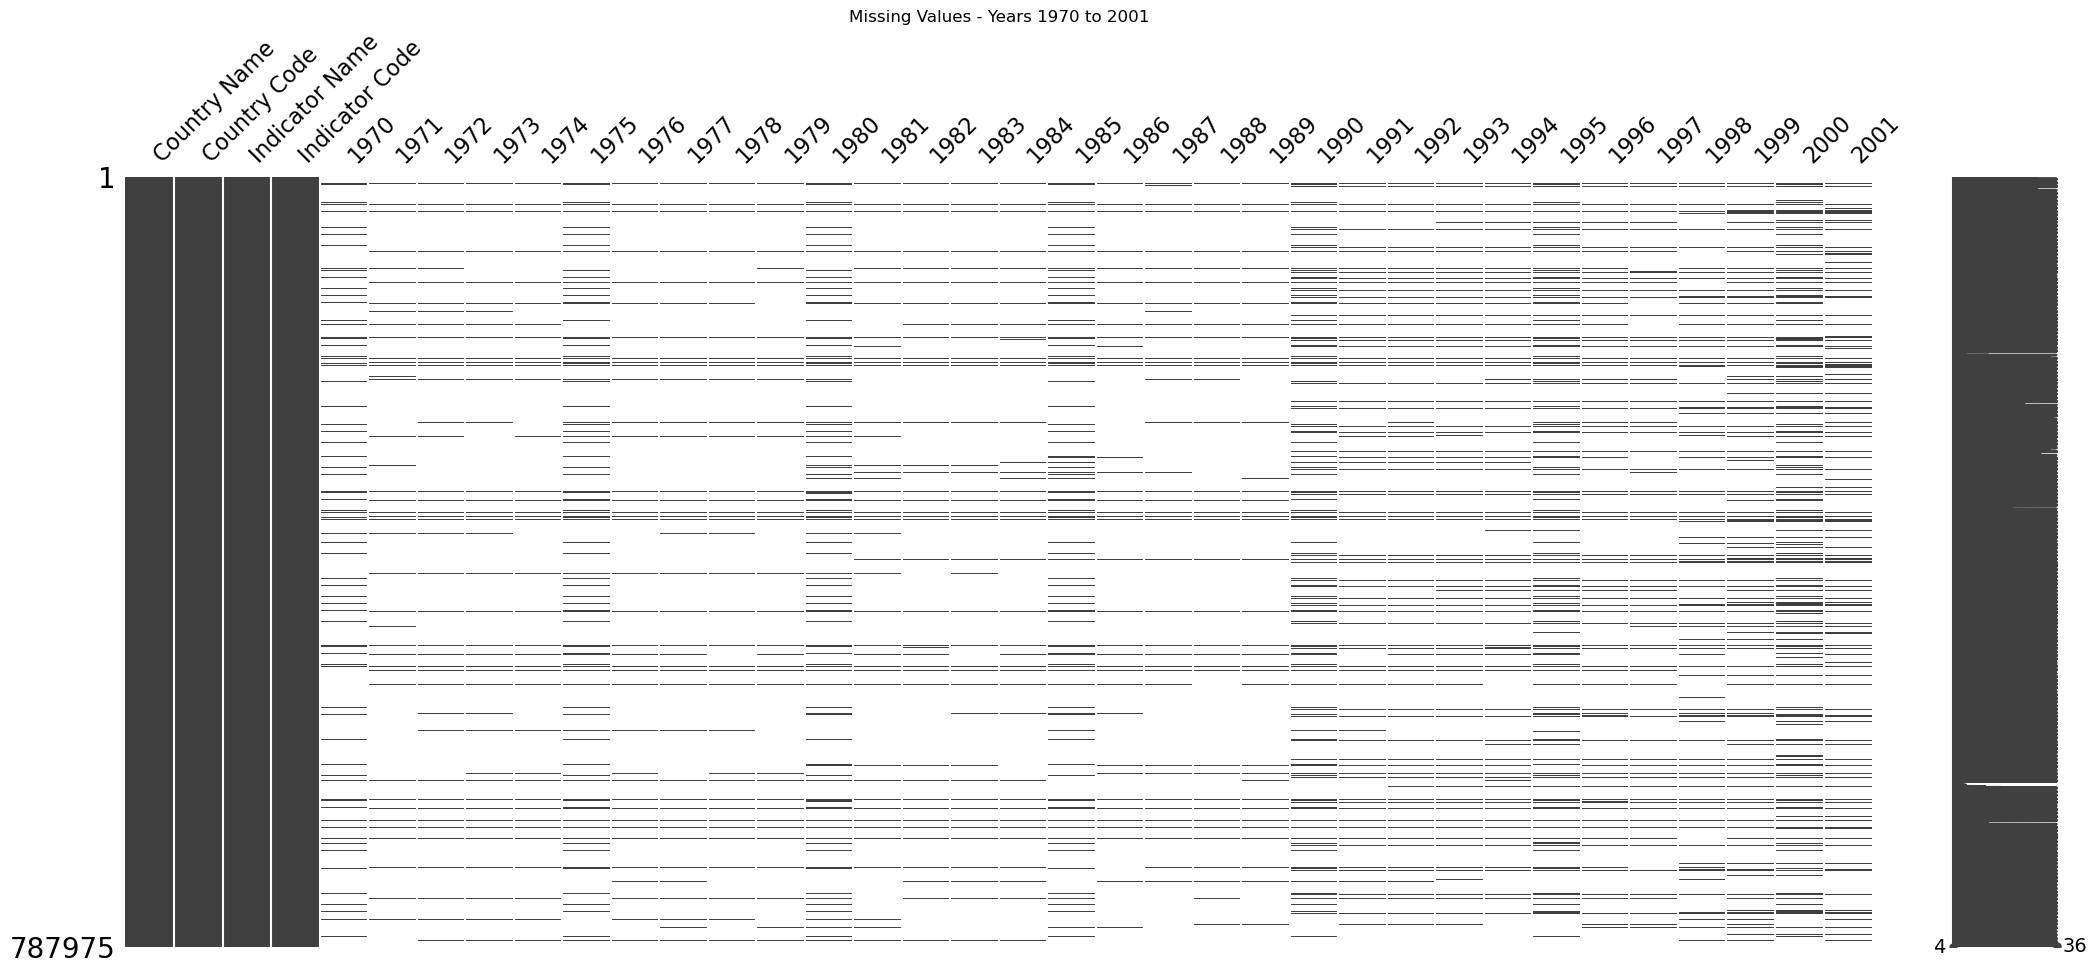

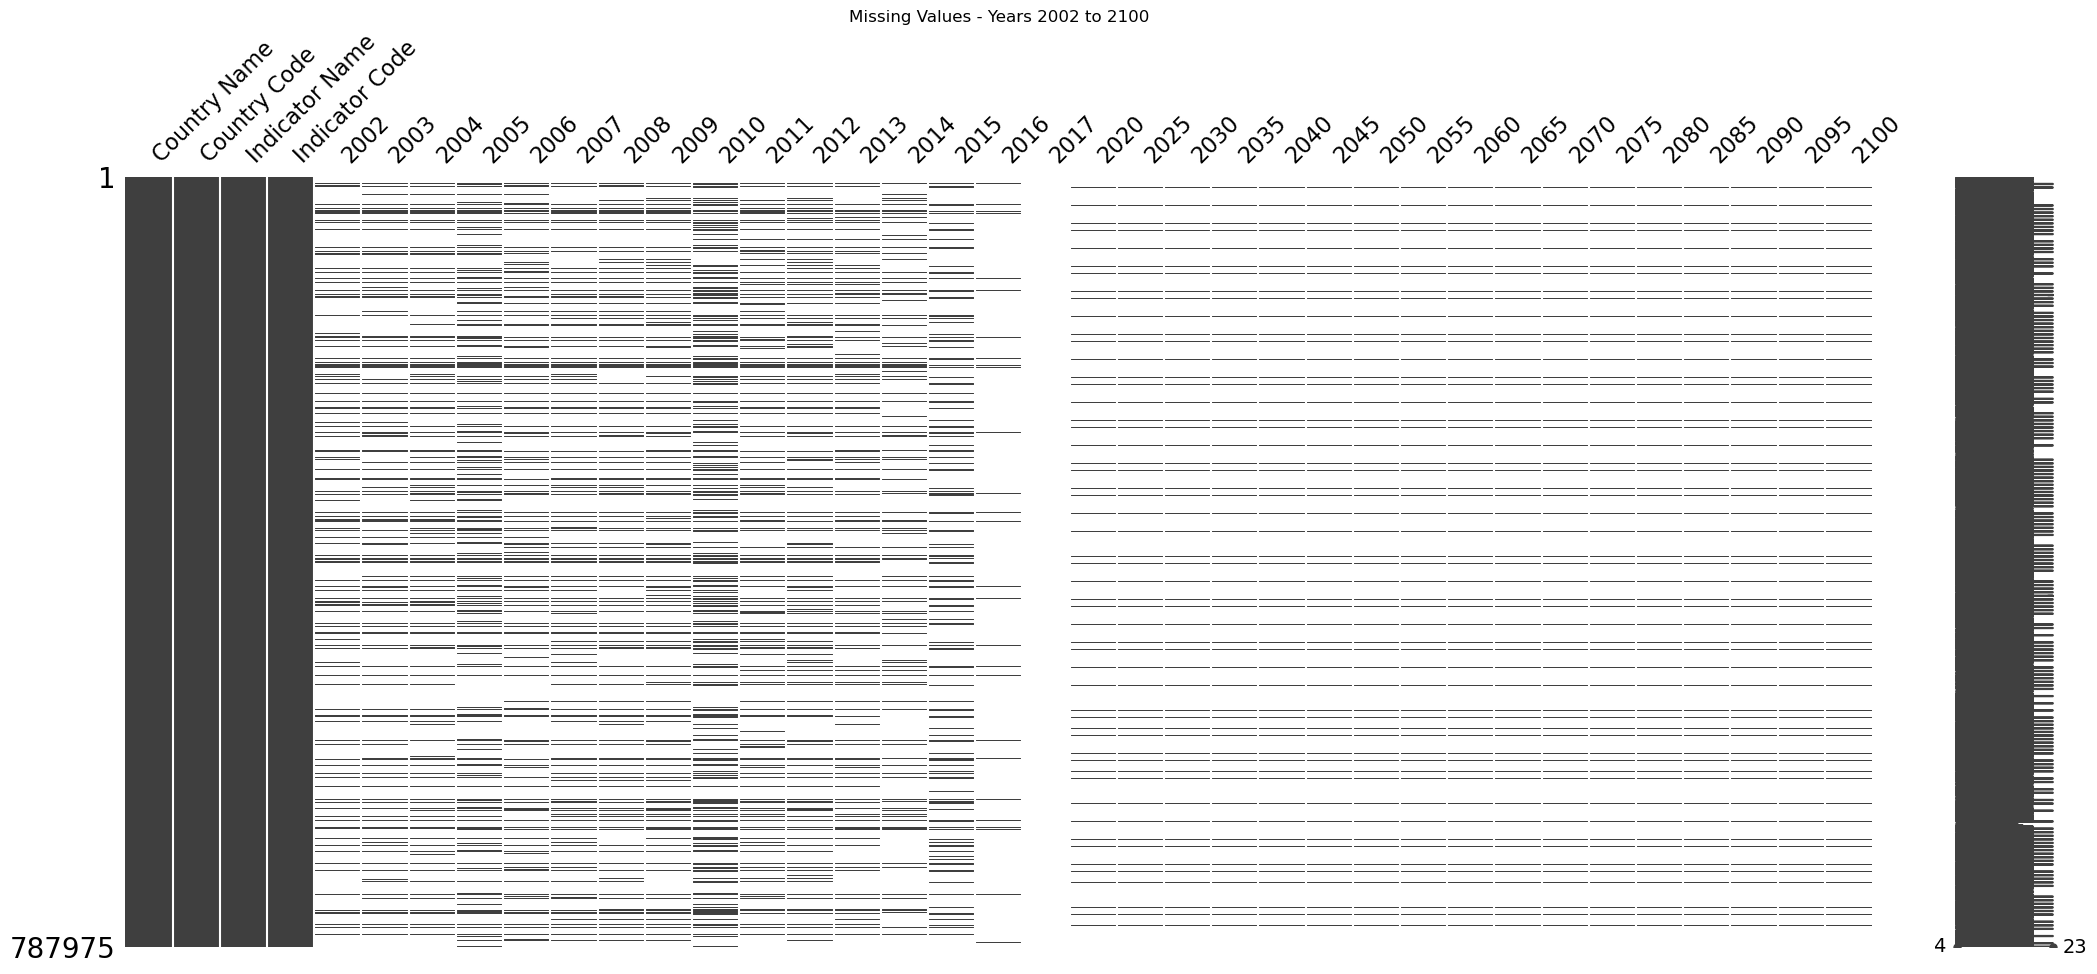

In [25]:
# show all the missing values throughout years

# Identify actual year columns in the DataFrame
all_cols = indicator_values.columns.tolist()
year_cols = [col for col in all_cols if col.isdigit()]

# Split year columns into two groups
half = len(year_cols) // 2
years_group1 = year_cols[:half]
years_group2 = year_cols[half:]


# Plot missingno matrix for the first group of years
msno.matrix(indicator_values[['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + years_group1])
plt.title('Missing Values - Years 1970 to ' + years_group1[-1])
plt.show()

# Plot missingno matrix for the second group of years
msno.matrix(indicator_values[['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'] + years_group2])
plt.title('Missing Values - Years ' + years_group2[0] + ' to 2100')
plt.show()

### Processing 2

All the data before 2010 is discarded as considered to be old. The indicator data is well populated from 2010 to 2015.

 as we find oursekves in the year 2025, hence deleting the data from 2025 to beyind as there are projections and the data was last uploaded in Oct 2024.

in addition, we also drop 2020 as the same celles seem to be filled as the following years which may be related to estimations. Hence, we keep the range from 2010 to 2016.

then add columns from 2017 to 2025.


In [26]:
# Drop columns for years 1970 to 2007 and 2025 to 2100
years_to_drop = [str(year) for year in range(1970, 2008)] + [str(year) for year in range(2025, 2101)]
indicator_values = indicator_values.drop(columns=years_to_drop, errors='ignore')

# Drop columns that start with "Unnamed"
unnamed_cols = [col for col in indicator_values.columns if col.startswith('Unnamed')]
indicator_values = indicator_values.drop(columns=unnamed_cols, errors='ignore')

# Add columns for years 2017 to 2025 with NaN values
years_to_add = [str(year) for year in range(2017, 2025)]
for year in years_to_add:
    if year not in indicator_values.columns:
        indicator_values[year] = np.nan


# Display the first few rows and columns to verify the changes
display(indicator_values.columns.tolist())

['Country Name',
 'Country Code',
 'Indicator Name',
 'Indicator Code',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2020',
 '2018',
 '2019',
 '2021',
 '2022',
 '2023',
 '2024']

# seriescode_description

"""


### Description
This table contains:
- **`country`**: Name or code of the country.
- **`series_code`**: Unique identifier for the indicator series.
- **`description`**: Likely a note about whether or how the series code applies to the country and the source of data.

### Assessment

- This table is **irrelevant** for the current analysis, as it does not provide actionable or necessary information for the project's objectives.
- No further exploration of this file is required.
"""



In [27]:
seriescode_description = pd.read_csv('EdStatsCountrySeries.csv')
seriescode_description.head()

,CountryCode,SeriesCode,DESCRIPTION,Unnamed: 3
0,ABW,SP.POP.TOTL,Data sources : United Nations World Population...,NaN
1,ABW,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
2,AFG,SP.POP.GROW,Data sources: United Nations World Population ...,NaN
3,AFG,NY.GDP.PCAP.PP.CD,Estimates are based on regression.,NaN
4,AFG,SP.POP.TOTL,Data sources : United Nations World Population...,NaN


In [28]:
seriescode_description.shape

(613, 4)

# Country_characteristics


"""


### Description
This table contains **country-level metadata**, including:
- **`country`**: Name or code of the country.
- **`currency`**: Official currency of the country.
- **`income_group`**: Classification of the country by income level (e.g., low-income, high-income).
- **`lending_category`**: Classification related to lending eligibility or terms.
- **`system_of_accounts`**: Accounting standards or systems used.
- **`survey_dates`**: Dates and explanations of surveys conducted (e.g., PPP surveys).

The table provides **characteristics of countries**, such as economic classifications and survey timelines.

### Assessment
- While the **`income_group`** variable is relevant.
- The `indicators_values` dataframe already includes all necessary indicator data, including PPP and technology-related metrics (e.g., internet and computer penetration).
- As a result, this table is not considered in further analysis.
"""
```

In [29]:
country_characteristics = pd.read_csv('EdStatsCountry.csv')
country_characteristics.head()

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,National accounts base year,National accounts reference year,SNA price valuation,Lending category,Other groups,System of National Accounts,Alternative conversion factor,PPP survey year,Balance of Payments Manual in use,External debt Reporting status,System of trade,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data,Unnamed: 31
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,SNA data for 2000-2011 are updated from offici...,Latin America & Caribbean,High income: nonOECD,AW,2000,NaN,Value added at basic prices (VAB),NaN,NaN,Country uses the 1993 System of National Accou...,NaN,NaN,"IMF Balance of Payments Manual, 6th edition.",NaN,Special trade system,NaN,NaN,2010,NaN,NaN,Yes,NaN,NaN,2012.0,NaN,NaN
1,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,Fiscal year end: March 20; reporting period fo...,South Asia,Low income,AF,2002/03,NaN,Value added at basic prices (VAB),IDA,HIPC,Country uses the 1993 System of National Accou...,NaN,NaN,NaN,Actual,General trade system,Consolidated central government,General Data Dissemination System (GDDS),1979,"Multiple Indicator Cluster Survey (MICS), 2010/11","Integrated household survey (IHS), 2008",NaN,2013/14,NaN,2012.0,2000,NaN
2,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,"April 2013 database update: Based on IMF data,...",Sub-Saharan Africa,Upper middle income,AO,2002,NaN,Value added at producer prices (VAP),IBRD,NaN,Country uses the 1993 System of National Accou...,1991–96,2005,"IMF Balance of Payments Manual, 6th edition.",Actual,Special trade system,Budgetary central government,General Data Dissemination System (GDDS),1970,"Malaria Indicator Survey (MIS), 2011","Integrated household survey (IHS), 2008",NaN,2015,NaN,NaN,2005,NaN
3,ALB,Albania,Albania,Republic of Albania,AL,Albanian lek,NaN,Europe & Central Asia,Upper middle income,AL,Original chained constant price data are resca...,1996.0,Value added at basic prices (VAB),IBRD,NaN,Country uses the 1993 System of National Accou...,NaN,Rolling,"IMF Balance of Payments Manual, 6th edition.",Actual,General trade system,Budgetary central government,General Data Dissemination System (GDDS),2011,"Demographic and Health Survey (DHS), 2008/09",Living Standards Measurement Study Survey (LSM...,Yes,2012,2010.0,2012.0,2006,NaN
4,AND,Andorra,Andorra,Principality of Andorra,AD,Euro,NaN,Europe & Central Asia,High income: nonOECD,AD,1990,NaN,NaN,NaN,NaN,Country uses the 1968 System of National Accou...,NaN,NaN,NaN,NaN,Special trade system,NaN,NaN,2011. Population figures compiled from adminis...,NaN,NaN,Yes,NaN,NaN,2006.0,NaN,NaN


# ANALYSIS OF CONSOLIDATED DATA




### Processing 1: Merge and choose indicators
- Combine data from all retained tables.
- **Merge keys**: Use **`Indicator Code`** and **`Country Code`** as the primary keys for merging.
- The data is merged such that the resultant table has:

**Indicator_values contains only the list if 19 indicators chosen among the indicator_data based on professional judgement.**

In [30]:
#Merge the dataframes to acheive a consilidated table



consolidated_table = pd.merge(
    indicator_values,
    indicator_data,
    left_on='Indicator Code',  # Adjust this to match the actual column name in indicator_values
    right_on='Series Code', # Adjust this to match the actual column name in indicator_data
    how="inner"
)

consolidated_table.drop(columns=['Series Code', 'Indicator Name_y'], inplace=True)
consolidated_table.rename(columns={'Indicator Name_x': 'Indicator Name'}, inplace=True)

print(consolidated_table.shape)


consolidated_table = consolidated_table[['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']]
consolidated_table.head()

(3870, 21)


,Country Name,Country Code,Indicator Name,Indicator Code,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,AFG,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,4.743679e+01,5.062723e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,"Adjusted net enrolment rate, upper secondary, ...",UIS.NERA.3,NaN,NaN,NaN,3.133262e+01,3.241703e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,2.032719e+06,2.190878e+06,2.392465e+06,2.508900e+06,2.577715e+06,2.671830e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,NaN,9.750400e+04,NaN,NaN,2.628740e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,GDP at market prices (constant 2005 US$),NY.GDP.MKTP.KD,1.593680e+10,1.691113e+10,1.935220e+10,1.973134e+10,1.999032e+10,2.021272e+10,2.066392e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



### Processing 2 : fill rate evaluation and further selection of indicators
- Evaluate the **fill rates** for each selected indicator and for each year.
- Calculate the **average fill rate** across all years for each indicator.
- Drop all the indicators with **low fill rates**.

Post-Filtering
- Retain a **further restrained list of indicators** based on the fill rate analysis and professional judgement.
- Apply this filtered list to the **consolidated table** for further processing.

In [31]:
columns_to_check = ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
 # columns for fill rate analysis
group_col = 'Indicator Name'               # column to group by

# -----------------------------# Step 1: Fill rate per group
# -----------------------------
fill_rate_per_group = consolidated_table.groupby(group_col)[columns_to_check].apply(lambda g: g.notna().mean())

# Compute average fill rate per group
fill_rate_per_group['avg_fill_rate'] = fill_rate_per_group.mean(axis=1)

# Rank groups based on average fill rate
fill_rate_per_group['rank'] = fill_rate_per_group['avg_fill_rate'].rank(ascending=False, method='dense')

# Fixed line: removed the 'name' parameter which is not valid for DataFrame.reset_index()
fill_rate_per_group.reset_index().to_csv('fill_rate_per_group.csv', index=False)


# -----------------------------
# Step 3: Rank columns by fill rate
# -----------------------------
fill_rate_overall = consolidated_table[columns_to_check].notna().mean()

ranked_fill_rate = fill_rate_overall.rank(ascending=False, method='dense')
print("\nRanked fill rate per column:\n", ranked_fill_rate)


Ranked fill rate per column:
 2010    1.0
2011    2.0
2012    3.0
2013    4.0
2014    5.0
2015    6.0
2016    7.0
2017    9.0
2018    9.0
2019    9.0
2020    8.0
2021    9.0
2022    9.0
2023    9.0
2024    9.0
dtype: float64


In [32]:
# List of indicators to keep
indicators = [
    'Enrolment in secondary general, both sexes (number)',
    'Enrolment in tertiary education, all programmes, both sexes (number)',
    'GDP at market prices (current US$)',
    'Government expenditure on secondary education as % of GDP (%)',
    'Government expenditure on tertiary education as % of GDP (%)',
    'Government expenditure per secondary student (US$)',
    'Government expenditure per tertiary student (US$)',
    'Internet users (per 100 people)'
]

# Filter the DataFrame
consolidated_table = consolidated_table[consolidated_table['Indicator Name'].isin(indicators)]
consolidated_table.shape

(1720, 19)

In [33]:
consolidated_table.head()

,Country Name,Country Code,Indicator Name,Indicator Code,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
2,Afghanistan,AFG,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,2.032719e+06,2.190878e+06,2.392465e+06,2.508900e+06,2.577715e+06,2.671830e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,NaN,9.750400e+04,NaN,NaN,2.628740e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,AFG,GDP at market prices (current US$),NY.GDP.MKTP.CD,1.593680e+10,1.793024e+10,2.053654e+10,2.004633e+10,2.005019e+10,1.921556e+10,1.946902e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,AFG,Government expenditure on secondary education ...,UIS.XGDP.23.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,AFG,Government expenditure on tertiary education a...,UIS.XGDP.56.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Graphs: Evolution of indicators over time

check how all the indicators are evolving over time.

create two seperate graphs for percentages and absolute numbers over time for all the indicators

only the years 2010 to 2016 are retained as they have real measurements to appreciate the evolution.

In [34]:
# Melt the consolidated table to long format
# Assuming consolidated_table still contains year columns 2010-2024 before the final pivot
melted_consolidated_table = consolidated_table.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Value',
    value_vars=[str(y) for y in range(2010, 2025)] # Explicitly melt year columns
)

# Convert Year to numeric
melted_consolidated_table['Year'] = pd.to_numeric(melted_consolidated_table['Year'])

# Filter for years 2010 to 2015
melted_consolidated_table_filtered = melted_consolidated_table[
    (melted_consolidated_table['Year'] >= 2010) & (melted_consolidated_table['Year'] <= 2015)
].copy() # Use .copy() to avoid SettingWithCopyWarning

# Calculate the average indicator value per year across countries where data is available
average_indicator_evolution = melted_consolidated_table_filtered.groupby(['Indicator Name', 'Year'])['Value'].mean().reset_index()

# Get unique indicator names
unique_indicators = average_indicator_evolution['Indicator Name'].unique()

**bold text**### Enrolment in secondary general, both sexes (number)

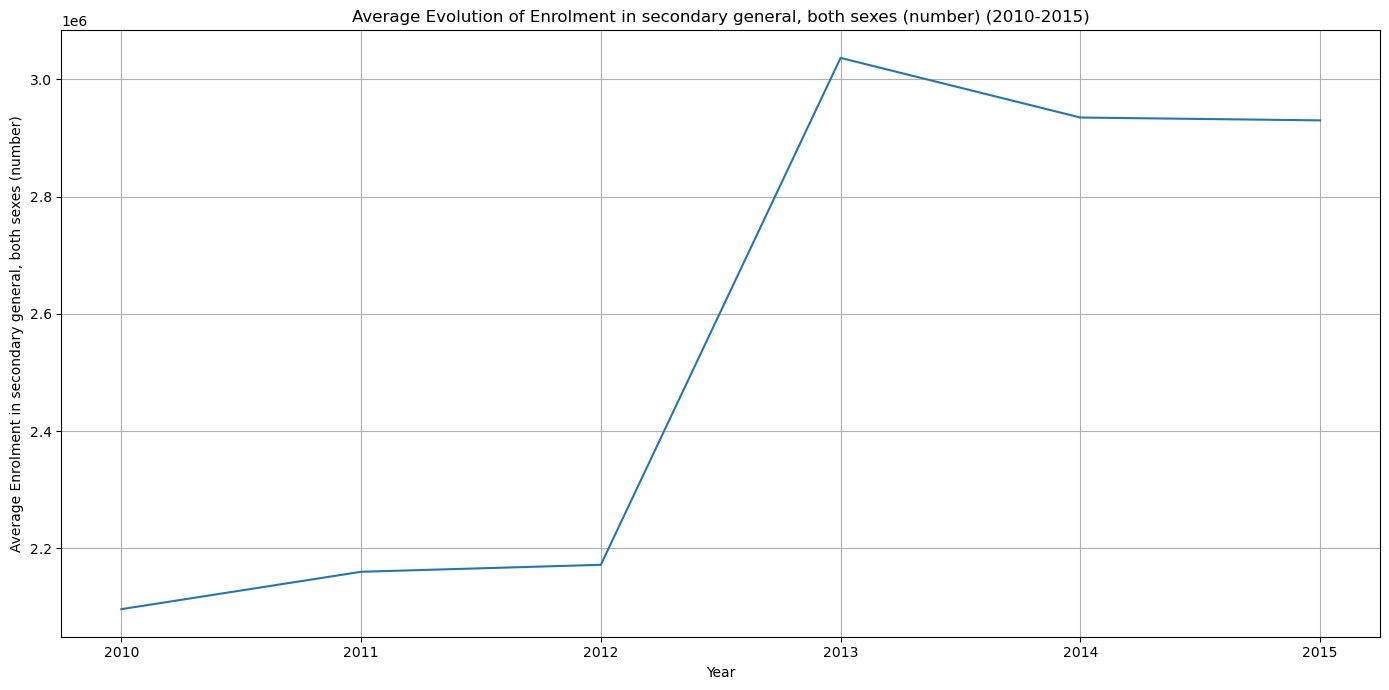

In [35]:
indicator = 'Enrolment in secondary general, both sexes (number)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Enrolment in tertiary education, all programmes, both sexes (number)

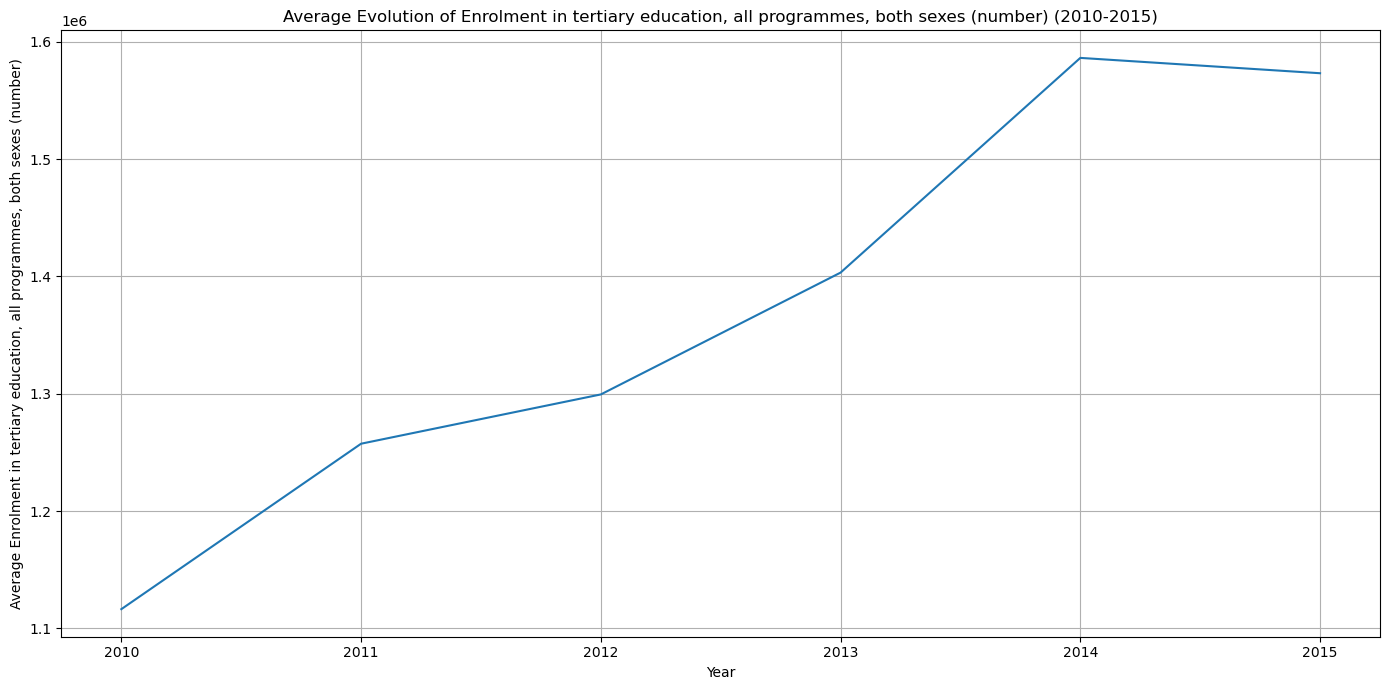

In [36]:
indicator = 'Enrolment in tertiary education, all programmes, both sexes (number)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### GDP at market prices (current US$)

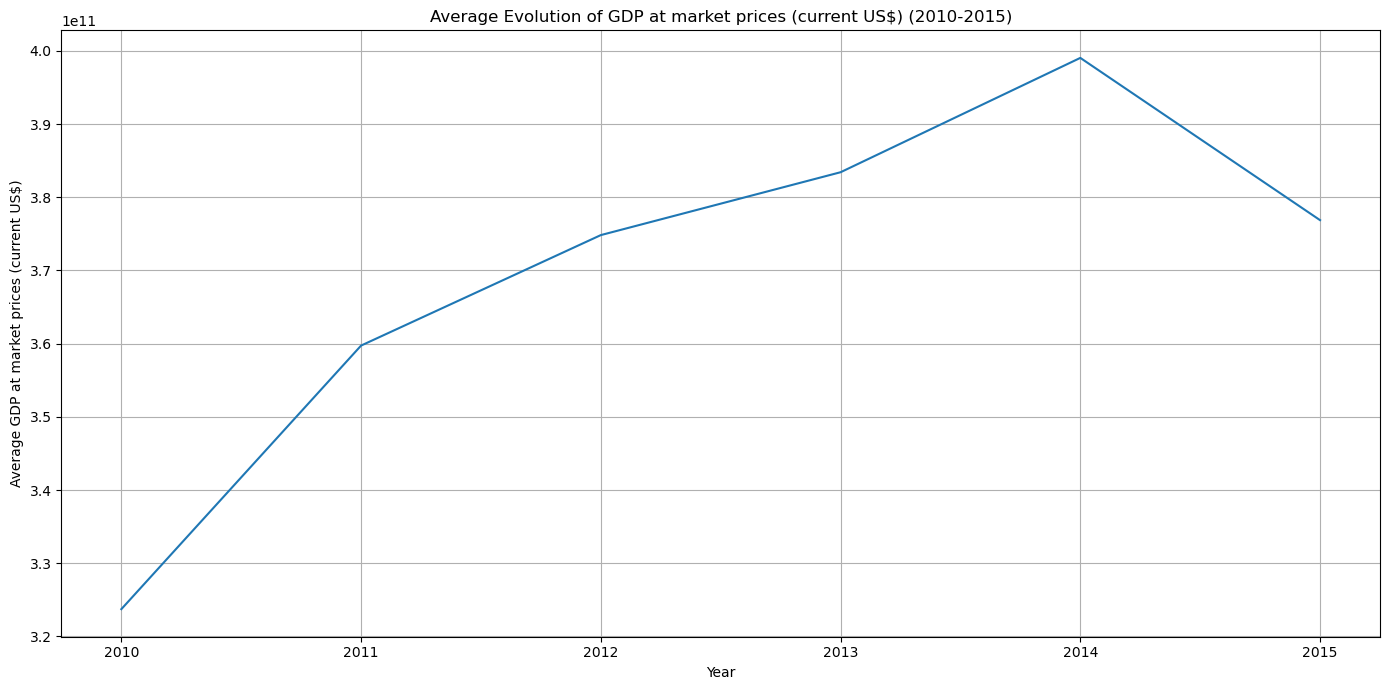

In [37]:
indicator = 'GDP at market prices (current US$)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Government expenditure on secondary education as % of GDP (%)

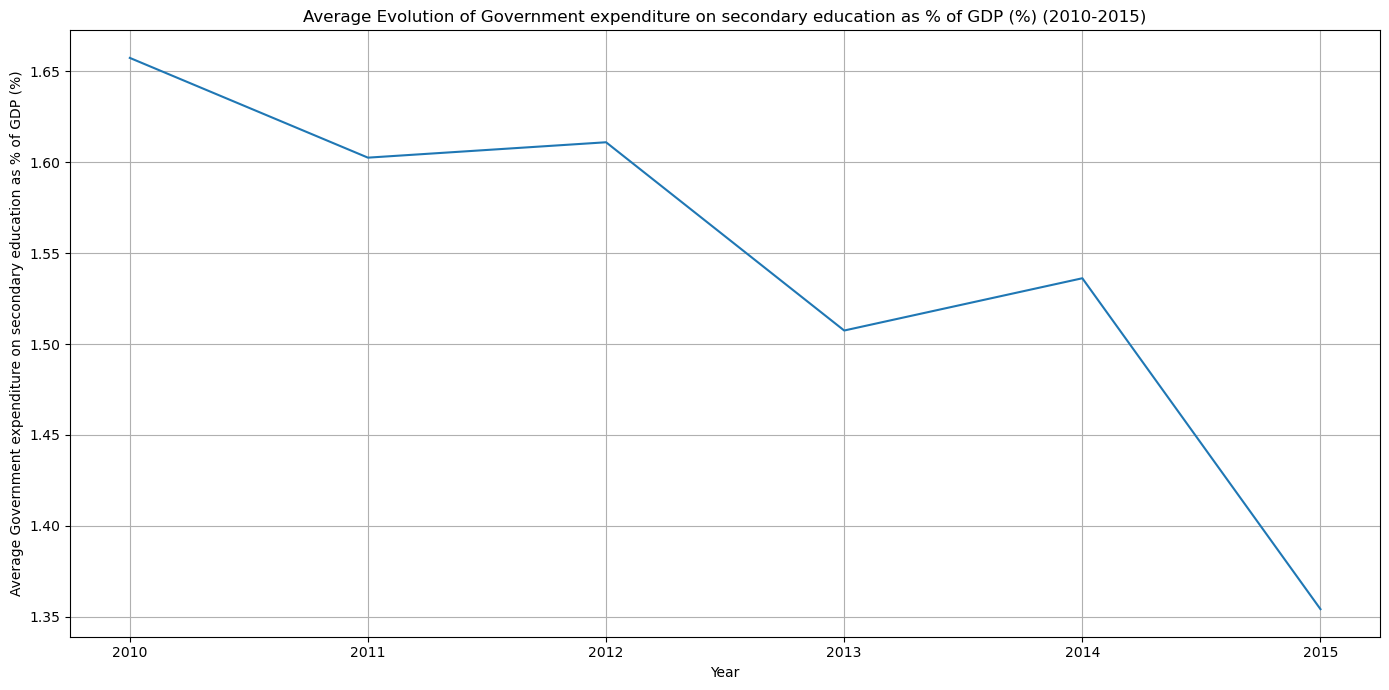

In [38]:
indicator = 'Government expenditure on secondary education as % of GDP (%)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Government expenditure on tertiary education as % of GDP (%)

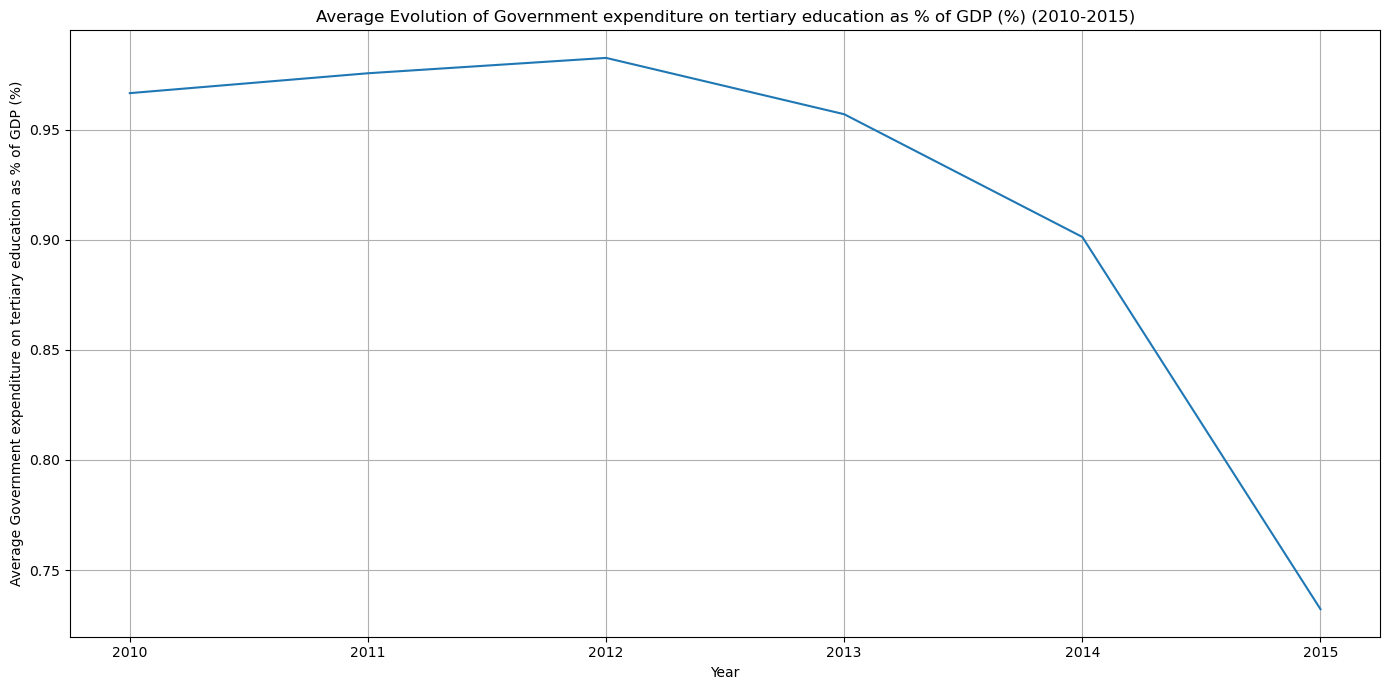

In [39]:
indicator = 'Government expenditure on tertiary education as % of GDP (%)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Government expenditure per secondary student (US$)

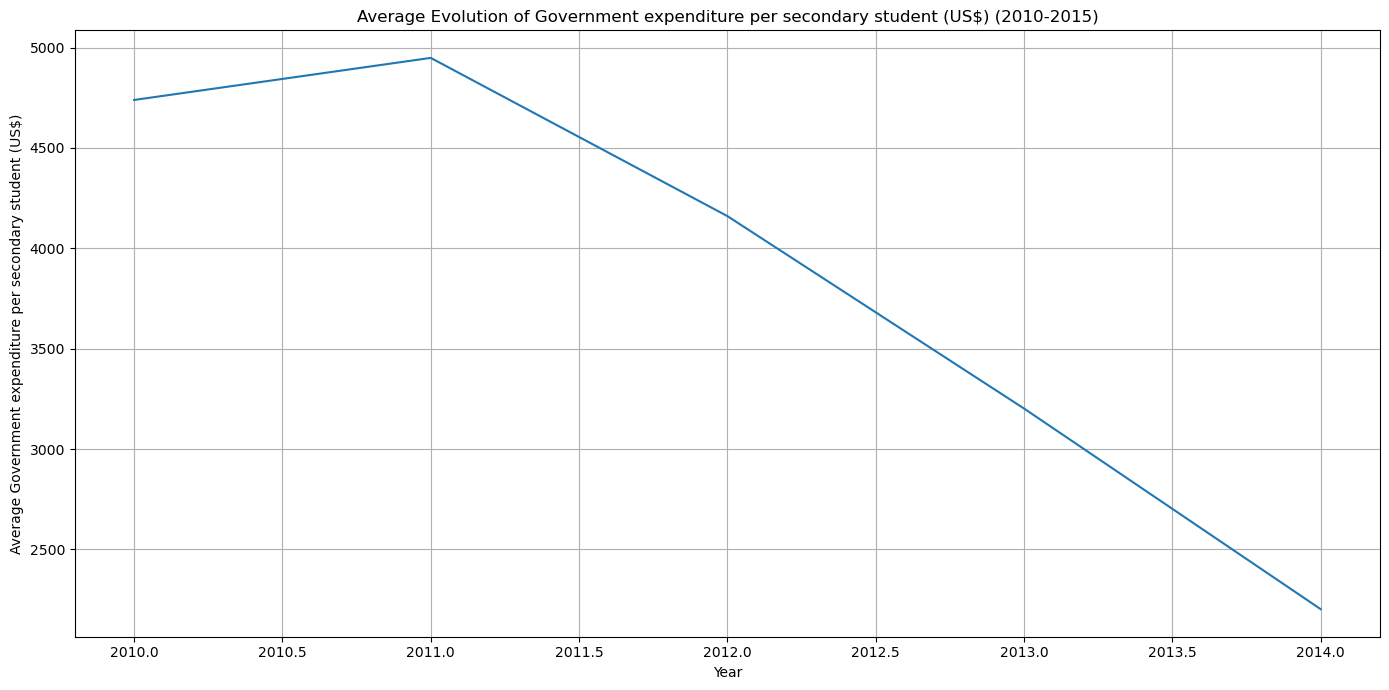

In [40]:
indicator = 'Government expenditure per secondary student (US$)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Government expenditure per tertiary student (US$)

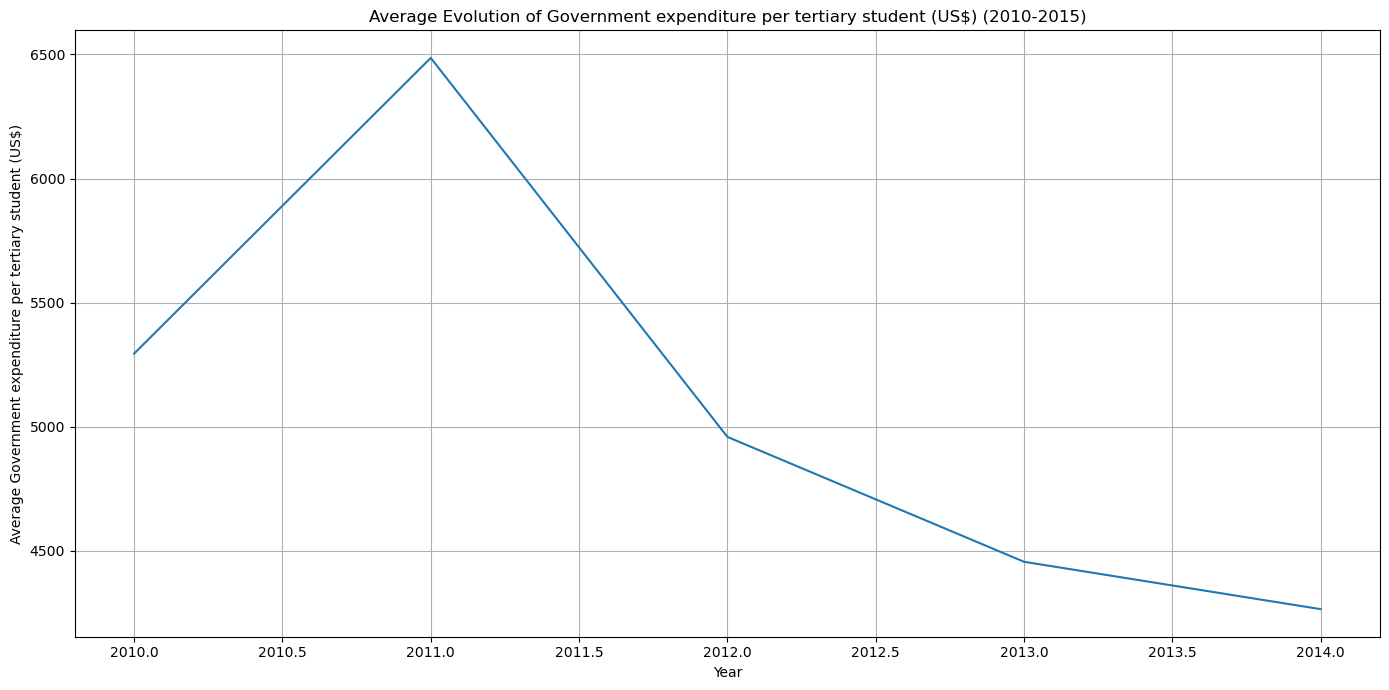

In [41]:
indicator = 'Government expenditure per tertiary student (US$)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

#### Internet users (per 100 people)

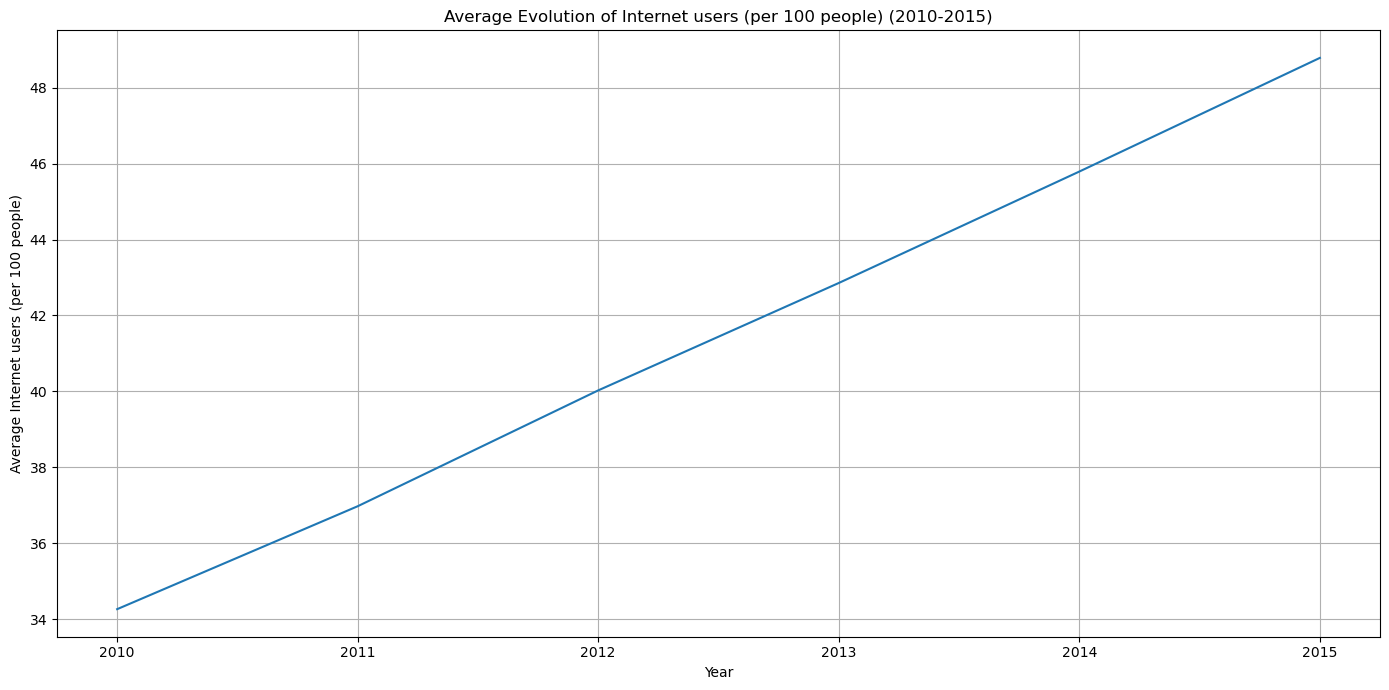

In [42]:
indicator = 'Internet users (per 100 people)'
indicator_data = average_indicator_evolution[average_indicator_evolution['Indicator Name'] == indicator]

plt.figure(figsize=(14, 7))
sns.lineplot(data=indicator_data, x='Year', y='Value')

# Set appropriate title and labels
plt.title(f'Average Evolution of {indicator} (2010-2015)')
plt.xlabel('Year')
plt.ylabel(f'Average {indicator}') # Use indicator name as y-axis label

plt.grid(True)
plt.tight_layout()
plt.show()

### Processing 3 : Correlation Analysis of indicators

**Melt the consolidated table**: Reshape the data to prepare for correlation analysis.
- **Compute Pearson correlation matrix**: Perform correlation analysis using the Pearson method.
- **Export correlation matrix**: Save the correlation matrix as a **flat file** for further analysis and indicator selection.
- Select statistically relevant indicators: Retain only the most statistically significant indicators from the correlation matrix for further analysis.
- All the indicators have been kept and some interestig correlations have been observed. However, they do not lead to removal of indicators from from further analysis.


After correlation matrix analysis:


- 'Enrolment in secondary general, both sexes (number)'
removed as correlated to 	'Enrolment in tertiary education, all programmes, both sexes (number)'
- 'Government expenditure per secondary student (US$)' removed as correlated to 'Government expenditure per tertiary student (US$)'

The resutant indicators do not have any significant correlation.






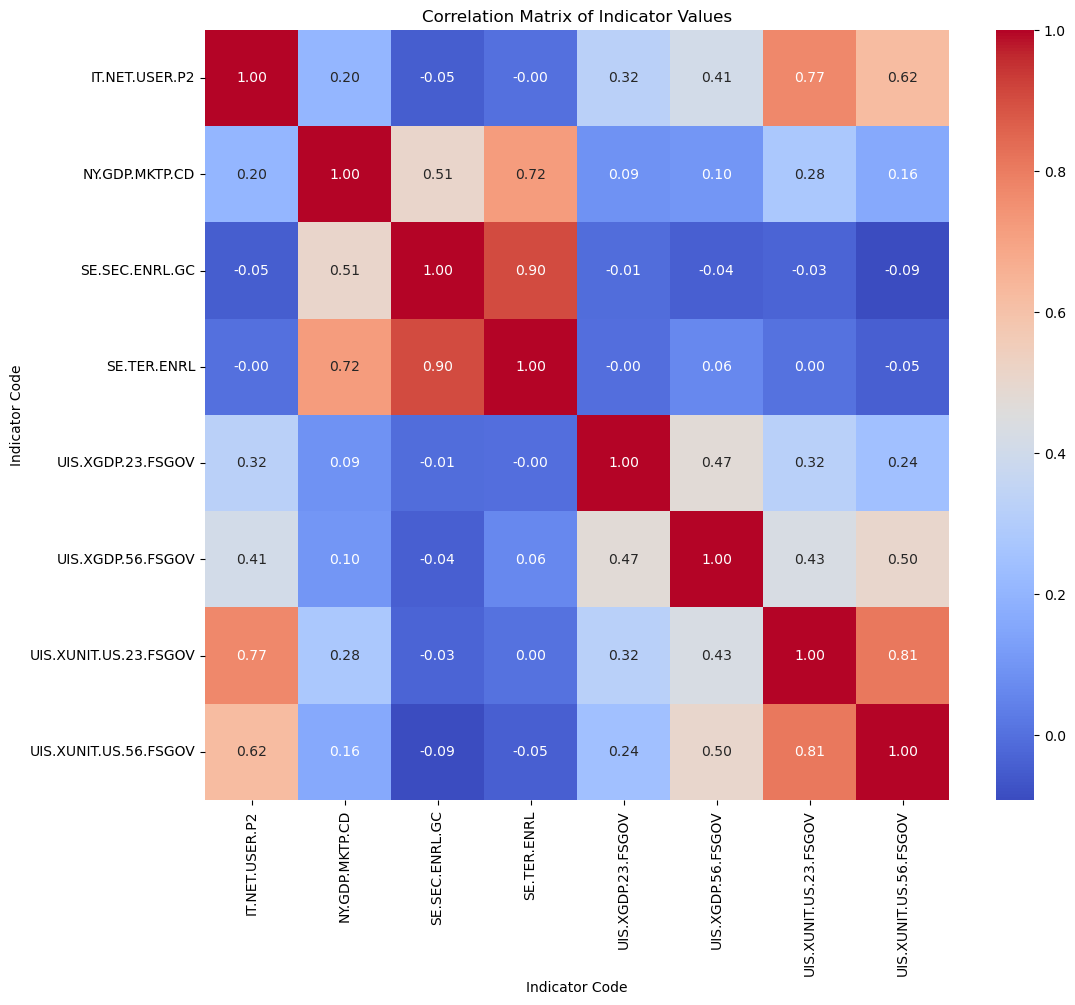

In [43]:
# make the table to perform correlation analysis

correlation_data = pd.melt(
   consolidated_table,
    id_vars=["Country Code", "Country Name", "Indicator Code", "Indicator Name"],
    value_vars=[ '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024'],
    var_name='Year',
    value_name='Value'
)

correlation_data = correlation_data [['Country Code','Indicator Code','Year','Value']]
# Drop rows with any NaN values
correlation_data.dropna(how='any', inplace=True)

# Pivot to wide format: one column per year
correlation_data = correlation_data.pivot_table(
    index=["Country Code","Year"],
    columns= "Indicator Code",
    values="Value",
    aggfunc="mean"
)

# Reset the index to make "Country Code" and "Year" regular columns again
correlation_data = correlation_data.reset_index()


# prepare a correlation matrix

correlation_data = correlation_data.drop(columns=['Country Code', 'Year'])

corr_matrix = correlation_data.corr(method='pearson')

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Indicator Values")
plt.show()


In [44]:
# Flatten correlation matrix
cols = corr_matrix.columns

# Create a mask for the upper triangle of the correlation matrix (excluding the diagonal)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# Apply the mask to the correlation matrix and stack the values
stacked_corr = corr_matrix.where(mask).stack()

# Rename the index levels before resetting the index
stacked_corr.index.set_names(['Indicator_1', 'Indicator_2'], inplace=True)

# Convert the stacked series to a DataFrame
corr_flat_table_simple = stacked_corr.reset_index()

# Rename the columns
corr_flat_table_simple.columns = ['Indicator_1', 'Indicator_2', 'Correlation']

# Sort by the absolute correlation value in descending order
corr_flat_table_simple['Absolute Correlation'] = corr_flat_table_simple['Correlation'].abs()
corr_flat_table_simple = corr_flat_table_simple.sort_values(by='Absolute Correlation', ascending=False).drop(columns='Absolute Correlation')


# Display the simplified flattened correlation table
display(corr_flat_table_simple.head())

,Indicator_1,Indicator_2,Correlation
13,SE.SEC.ENRL.GC,SE.TER.ENRL,0.904368
27,UIS.XUNIT.US.23.FSGOV,UIS.XUNIT.US.56.FSGOV,0.810305
5,IT.NET.USER.P2,UIS.XUNIT.US.23.FSGOV,0.771411
8,NY.GDP.MKTP.CD,SE.TER.ENRL,0.720190
6,IT.NET.USER.P2,UIS.XUNIT.US.56.FSGOV,0.622931


In [45]:
# Reload the original indicator data to get the 'Series Code' column
indicator_data_original = pd.read_csv('EdStatsSeries.csv')

# Merge to get description for Indicator_1
corr_flat_table_simple = pd.merge(
    corr_flat_table_simple,
    indicator_data_original[['Series Code', 'Indicator Name']], # Select only necessary columns
    left_on='Indicator_1',
    right_on='Series Code',
    how='left'
)

# Rename the 'Indicator Name' column and drop the 'Series Code'
corr_flat_table_simple.rename(columns={'Indicator Name': 'Indicator_1_Description'}, inplace=True)
corr_flat_table_simple.drop(columns='Series Code', inplace=True)

# Merge again to get description for Indicator_2
corr_flat_table_simple = pd.merge(
    corr_flat_table_simple,
    indicator_data_original[['Series Code', 'Indicator Name']], # Select only necessary columns
    left_on='Indicator_2',
    right_on='Series Code',
    how='left'
)

# Rename the 'Indicator Name' column and drop the 'Series Code'
corr_flat_table_simple.rename(columns={'Indicator Name': 'Indicator_2_Description'}, inplace=True)
corr_flat_table_simple.drop(columns='Series Code', inplace=True)

# Drop unnecessary columns, keeping only the ones we need
columns_to_keep = ['Indicator_1', 'Indicator_2', 'Correlation', 'Indicator_1_Description', 'Indicator_2_Description']
corr_flat_table_simple = corr_flat_table_simple[columns_to_keep]

# Export the simplified flattened correlation table to a CSV file
corr_flat_table_simple.to_csv('flattened_correlation_table_simple.csv', index=False)

print("Simplified flattened correlation table created and saved as 'flattened_correlation_table_simple.csv'")


# Display the updated table with descriptions and relevant columns
display(corr_flat_table_simple.head())

Simplified flattened correlation table created and saved as 'flattened_correlation_table_simple.csv'


,Indicator_1,Indicator_2,Correlation,Indicator_1_Description,Indicator_2_Description
0,SE.SEC.ENRL.GC,SE.TER.ENRL,0.904368,"Enrolment in secondary general, both sexes (nu...","Enrolment in tertiary education, all programme..."
1,UIS.XUNIT.US.23.FSGOV,UIS.XUNIT.US.56.FSGOV,0.810305,Government expenditure per secondary student (...,Government expenditure per tertiary student (US$)
2,IT.NET.USER.P2,UIS.XUNIT.US.23.FSGOV,0.771411,Internet users (per 100 people),Government expenditure per secondary student (...
3,NY.GDP.MKTP.CD,SE.TER.ENRL,0.720190,GDP (current US$),"Enrolment in tertiary education, all programme..."
4,IT.NET.USER.P2,UIS.XUNIT.US.56.FSGOV,0.622931,Internet users (per 100 people),Government expenditure per tertiary student (US$)


In [46]:
# List of indicators to remove
indicators_to_remove = [
    'Enrolment in secondary general, both sexes (number)',
    'Government expenditure per secondary student (US$)'
]

# Filter the consolidated table to remove the specified indicators
consolidated_table = consolidated_table[~consolidated_table['Indicator Name'].isin(indicators_to_remove)].copy()

# Display the shape of the filtered table to confirm removal
print(consolidated_table.shape)

# Display the first few rows of the filtered table
consolidated_table.head()

(1290, 19)


,Country Name,Country Code,Indicator Name,Indicator Code,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
3,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,NaN,9.750400e+04,NaN,NaN,2.628740e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,AFG,GDP at market prices (current US$),NY.GDP.MKTP.CD,1.593680e+10,1.793024e+10,2.053654e+10,2.004633e+10,2.005019e+10,1.921556e+10,1.946902e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,AFG,Government expenditure on secondary education ...,UIS.XGDP.23.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,AFG,Government expenditure on tertiary education a...,UIS.XGDP.56.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,Afghanistan,AFG,Government expenditure per tertiary student (US$),UIS.XUNIT.US.56.FSGOV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Processing 4: Indicator Selection and Missing Value Treatment


Drop all indicatoes that are correlated.
Eliminated indicators and reason :



Analyze missing values:

Use missingno to visualize and identify missing values in the consolidated table.
Impute missing values:

Fill missing values using the mean of available years for each indicator and country.
Apply interpolation and extrapolation for missing values at the start or end of the year range.
Constraint: No imputation is performed for countries that never had data for a specific indicator.

<Axes: >

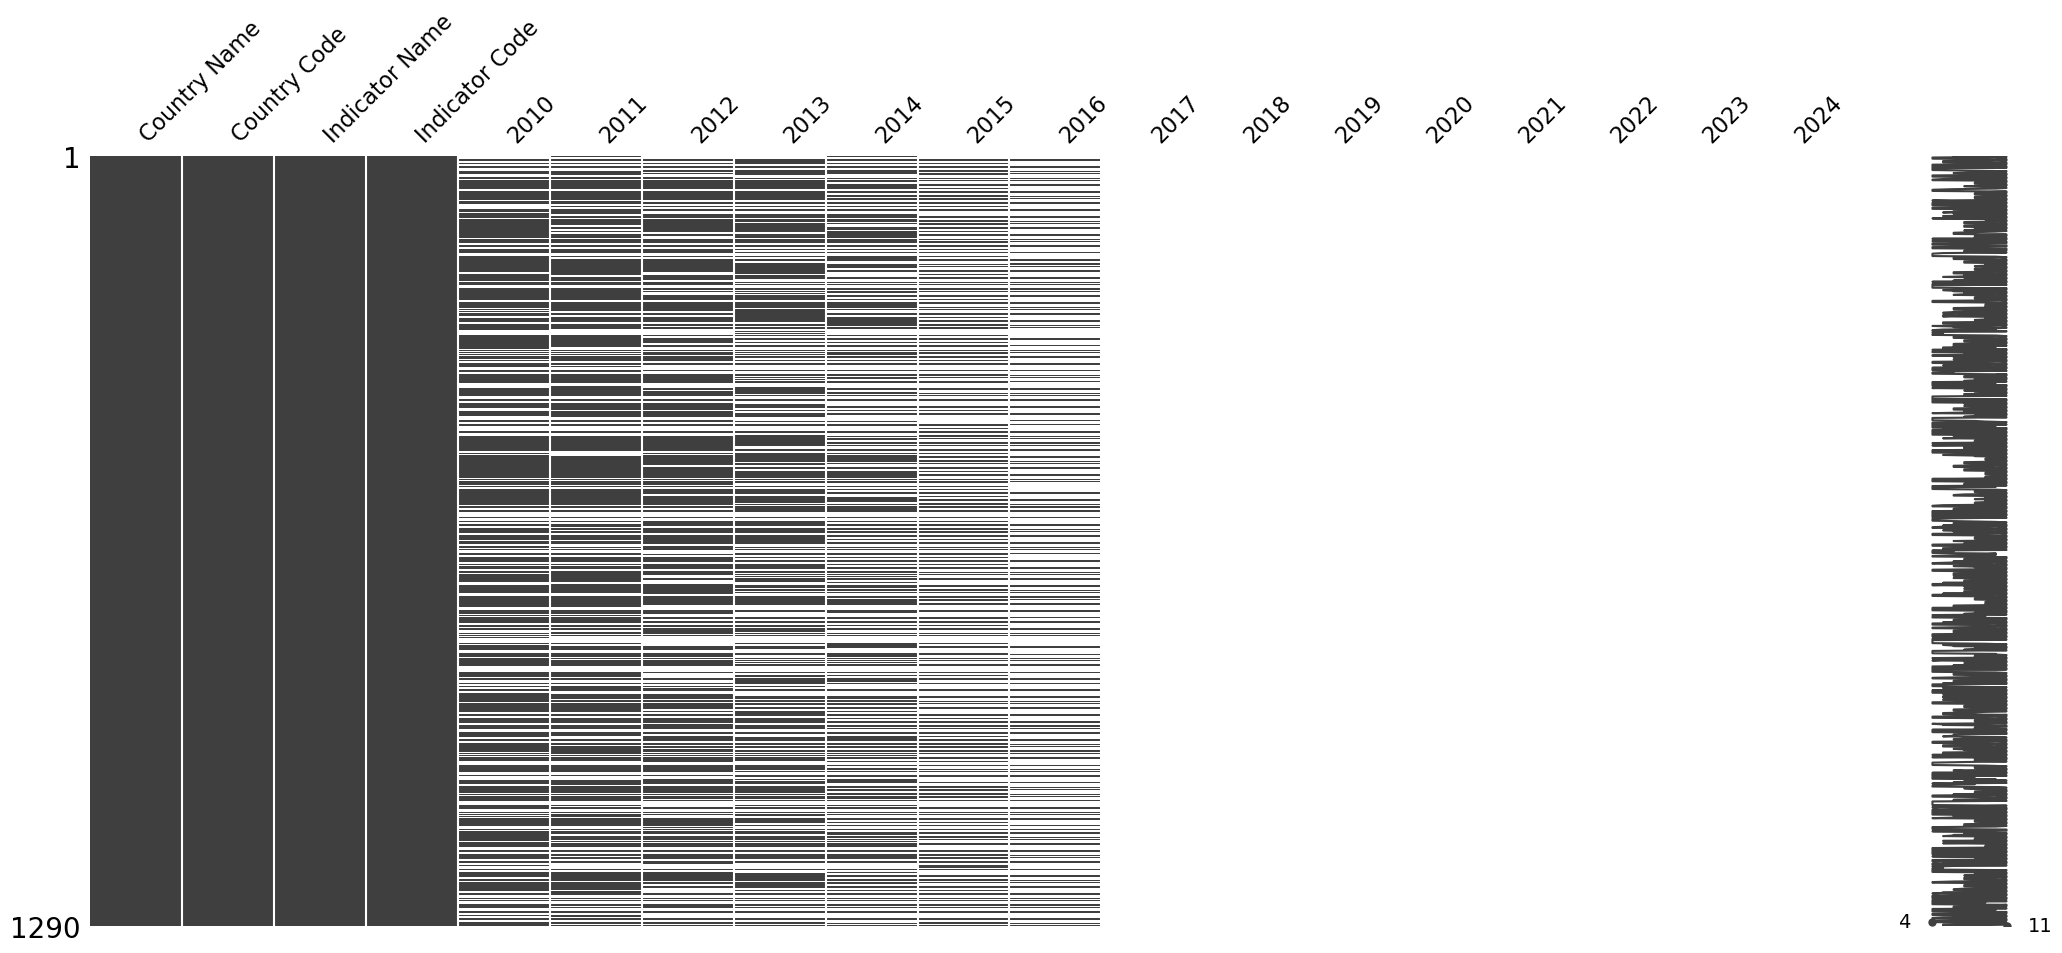

In [47]:
msno.matrix(consolidated_table)

<Axes: >

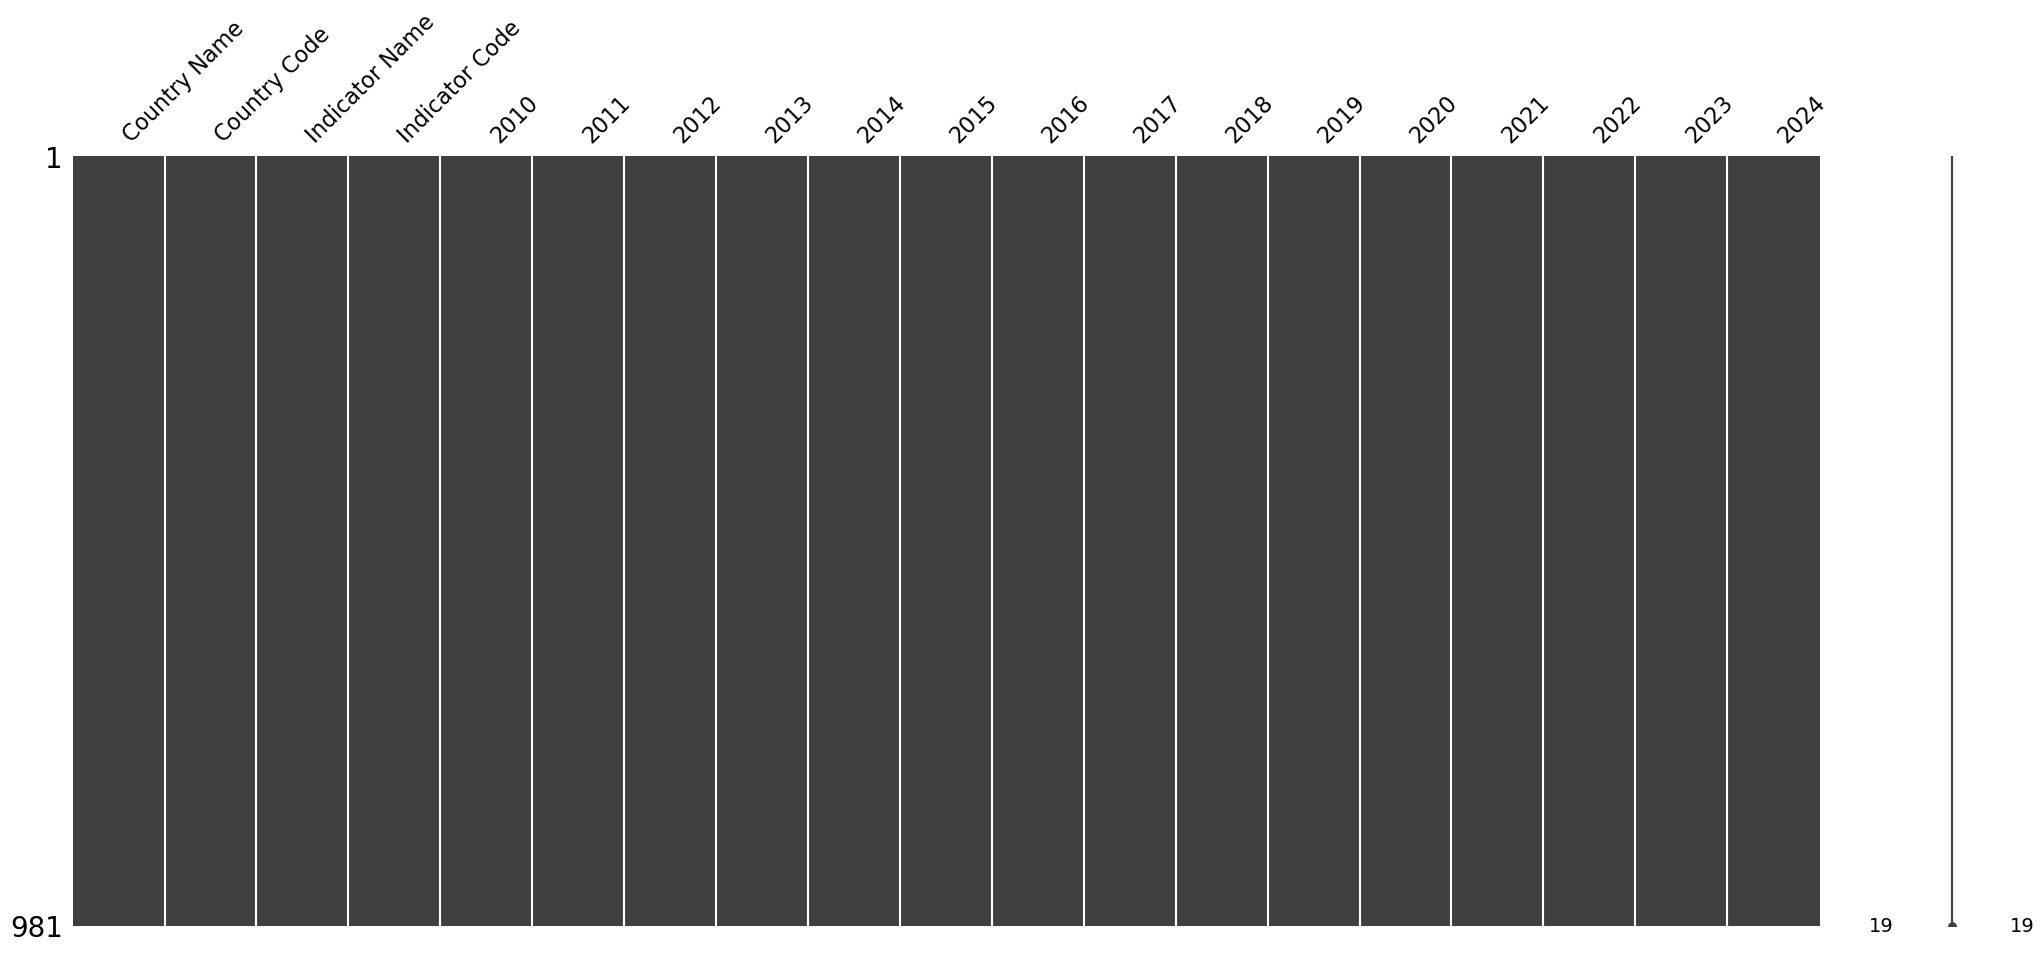

In [48]:
#fill missing values for indicators

# Identify the year columns
year_cols = [str(y) for y in range(2010, 2025)]

# Create a copy of the DataFrame to avoid SettingWithCopyWarning
consolidated_table_imputed = consolidated_table.copy()

# Fill missing values per Country + Indicator
for (country_code, country_name, indicator_code, indicator_name), group in consolidated_table_imputed.groupby([
    "Country Code", "Country Name", "Indicator Code", "Indicator Name"
]):
    # Get the indices for this group
    idx = group.index

    # Interpolate the values for this group
    interpolated_values = (
        group[year_cols]
        .interpolate(axis=1, limit_direction='both')  # interpolate gaps
        .ffill(axis=1)                               # forward fill edge NaNs
        .bfill(axis=1)                              # backward fill edge NaNs
    )

    # Update the consolidated_table_imputed with interpolated values using .loc
    consolidated_table_imputed.loc[idx, year_cols] = interpolated_values

# Assign the processed DataFrame back to consolidated_table
consolidated_table = consolidated_table_imputed.copy()

# Drop rows where all indicator values are missing across the year columns
consolidated_table.dropna(subset=year_cols, how='all', inplace=True)


# The code below should be outside the for loop and properly indented
# 1️⃣ Select only numeric columns
# This line seems out of place here based on the previous steps and variable names.
# Assuming it's not needed for the imputation fix, I will comment it out or remove it.
# If it's intended for a later step, it should be in a separate cell.
# numeric_data = indicator_values.select_dtypes(include=['float', 'int'])


msno.matrix(consolidated_table)

In [49]:
consolidated_table.head()

,Country Name,Country Code,Indicator Name,Indicator Code,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
3,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,9.750400e+04,9.750400e+04,1.526273e+05,2.077507e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05,2.628740e+05
5,Afghanistan,AFG,GDP at market prices (current US$),NY.GDP.MKTP.CD,1.593680e+10,1.793024e+10,2.053654e+10,2.004633e+10,2.005019e+10,1.921556e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10,1.946902e+10
14,Afghanistan,AFG,Internet users (per 100 people),IT.NET.USER.P2,4.000000e+00,5.000000e+00,5.454545e+00,5.900000e+00,7.000000e+00,8.260000e+00,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01,1.059573e+01
21,Albania,ALB,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,1.223260e+05,1.348770e+05,1.608390e+05,1.730290e+05,1.738190e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05,1.605270e+05
23,Albania,ALB,GDP at market prices (current US$),NY.GDP.MKTP.CD,1.192695e+10,1.289087e+10,1.231978e+10,1.277628e+10,1.322824e+10,1.133526e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10,1.186387e+10


## Processing: Melting the Consolidated Table

To prepare the data for reshaping and further analysis, the `consolidated_table` was melted from a wide format (years as columns) to a long format (a single 'Year' column and a single 'Value' column). This process makes it easier to work with the time-series data and perform operations like pivoting and normalization.

The resulting table, `melted_consolidated_table`, has the following columns:
- `Country Name`
- `Country Code`
- `Indicator Name`
- `Indicator Code`
- `Year`: The year of the observation.
- `Value`: The indicator value for that country, indicator, and year.

In [50]:
# Display the first few rows of the melted table
display(melted_consolidated_table.head())

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Afghanistan,AFG,"Enrolment in secondary general, both sexes (nu...",SE.SEC.ENRL.GC,2010,2.032719e+06
1,Afghanistan,AFG,"Enrolment in tertiary education, all programme...",SE.TER.ENRL,2010,NaN
2,Afghanistan,AFG,GDP at market prices (current US$),NY.GDP.MKTP.CD,2010,1.593680e+10
3,Afghanistan,AFG,Government expenditure on secondary education ...,UIS.XGDP.23.FSGOV,2010,NaN
4,Afghanistan,AFG,Government expenditure on tertiary education a...,UIS.XGDP.56.FSGOV,2010,NaN


In [51]:
# Melt the consolidated table to long format
melted_consolidated_table = consolidated_table.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Value',
    value_vars=[str(y) for y in range(2010, 2025)] # Assuming these are the relevant year columns
)

# Pivot the table to have years in rows and indicators in columns
reshaped_table = melted_consolidated_table.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Indicator Name',
    values='Value'
).reset_index()

# Display the reshaped table
display(reshaped_table.head())

Indicator Name,Country Name,Country Code,Year,"Enrolment in tertiary education, all programmes, both sexes (number)",GDP at market prices (current US$),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (US$),Internet users (per 100 people)
0,Afghanistan,AFG,2010,97504.000000,1.593680e+10,NaN,NaN,NaN,4.000000
1,Afghanistan,AFG,2011,97504.000000,1.793024e+10,NaN,NaN,NaN,5.000000
2,Afghanistan,AFG,2012,152627.333333,2.053654e+10,NaN,NaN,NaN,5.454545
3,Afghanistan,AFG,2013,207750.666667,2.004633e+10,NaN,NaN,NaN,5.900000
4,Afghanistan,AFG,2014,262874.000000,2.005019e+10,NaN,NaN,NaN,7.000000


In [52]:
# Check for missing values in the reshaped table
missing_values_reshaped = reshaped_table.isna().mean().sort_values(ascending=False)

print("Percentage of Missing Values in the Reshaped Table:")
display(missing_values_reshaped)

Percentage of Missing Values in the Reshaped Table:


Indicator Name
Government expenditure per tertiary student (US$)                       0.431925
Government expenditure on tertiary education as % of GDP (%)            0.356808
Government expenditure on secondary education as % of GDP (%)           0.323944
Enrolment in tertiary education, all programmes, both sexes (number)    0.192488
GDP at market prices (current US$)                                      0.046948
Internet users (per 100 people)                                         0.042254
Country Name                                                            0.000000
Country Code                                                            0.000000
Year                                                                    0.000000
dtype: float64

In [53]:
# Calculate Education Expenditure using Formula 1
# Enrolment in tertiary education, all programmes, both sexes (number) * Government expenditure per tertiary student (US$)
reshaped_table['Education Expenditure (Calculation 1)'] = (
    reshaped_table['Enrolment in tertiary education, all programmes, both sexes (number)'] *
    reshaped_table['Government expenditure per tertiary student (US$)']*2
)

# Calculate Education Expenditure using Formula 2
# GDP at market prices (current US$) * (Government expenditure on secondary education as % of GDP (%) + Government expenditure on tertiary education as % of GDP (%))
# Note: The percentage indicators need to be converted to decimals by dividing by 100
reshaped_table['Education Expenditure (Calculation 2)'] = (
    reshaped_table['GDP at market prices (current US$)'] *
    ((reshaped_table['Government expenditure on secondary education as % of GDP (%)'] / 100) +
     (reshaped_table['Government expenditure on tertiary education as % of GDP (%)'] / 100))
)

# Display the reshaped table with the new expenditure columns
display(reshaped_table.head())

Indicator Name,Country Name,Country Code,Year,"Enrolment in tertiary education, all programmes, both sexes (number)",GDP at market prices (current US$),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (US$),Internet users (per 100 people),Education Expenditure (Calculation 1),Education Expenditure (Calculation 2)
0,Afghanistan,AFG,2010,97504.000000,1.593680e+10,NaN,NaN,NaN,4.000000,NaN,NaN
1,Afghanistan,AFG,2011,97504.000000,1.793024e+10,NaN,NaN,NaN,5.000000,NaN,NaN
2,Afghanistan,AFG,2012,152627.333333,2.053654e+10,NaN,NaN,NaN,5.454545,NaN,NaN
3,Afghanistan,AFG,2013,207750.666667,2.004633e+10,NaN,NaN,NaN,5.900000,NaN,NaN
4,Afghanistan,AFG,2014,262874.000000,2.005019e+10,NaN,NaN,NaN,7.000000,NaN,NaN


In [54]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# Calculate Education Expenditure using Formula 1
# Enrolment in tertiary education, all programmes, both sexes (number) * Government expenditure per tertiary student (US$)
reshaped_table['Education Expenditure (Calculation 1)'] = (
    reshaped_table['Enrolment in tertiary education, all programmes, both sexes (number)'] *
    reshaped_table['Government expenditure per tertiary student (US$)']
)

# Calculate Education Expenditure using Formula 2
# GDP at market prices (current US$) * (Government expenditure on secondary education as % of GDP (%) + Government expenditure on tertiary education as % of GDP (%))
# Note: The percentage indicators need to be converted to decimals by dividing by 100
reshaped_table['Education Expenditure (Calculation 2)'] = (
    reshaped_table['GDP at market prices (current US$)'] *
    ((reshaped_table['Government expenditure on secondary education as % of GDP (%)'] / 100) +
     (reshaped_table['Government expenditure on tertiary education as % of GDP (%)'] / 100))
)

# Calculate the average of the two education expenditure calculations
# Handle cases where one of the calculations resulted in NaN
# Modified to calculate the average only if BOTH calculations are not NaN
reshaped_table['Average Education Expenditure'] = reshaped_table.apply(
    lambda row: (row['Education Expenditure (Calculation 1)'] + row['Education Expenditure (Calculation 2)']) / 2
    if pd.notna(row['Education Expenditure (Calculation 1)']) and pd.notna(row['Education Expenditure (Calculation 2)'])
    else np.nan,
    axis=1
)

# Identify the columns to be used for the final potential score calculation
# This includes the average education expenditure and the internet users indicator
potential_indicators = [
    'Average Education Expenditure',
    'Internet users (per 100 people)'
]

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply normalization to the potential indicator columns
# Fit and transform only on the selected columns
# Note: MinMaxScaler by default ignores NaNs, which is appropriate here for the scaling itself
reshaped_table[potential_indicators] = scaler.fit_transform(reshaped_table[potential_indicators])

# Define weights for the final potential score (these are example weights)
# Adjusting based on the user's initial request for internet users importance
weights = {
    'Average Education Expenditure': 0.85,  # Weight for education spending
    'Internet users (per 100 people)': 0.15 # Weight for internet users
}

# Calculate the final education potential score
# Ensure that the weighted sum handles potential NaN values after normalization
# Modified to calculate score only if both 'Average Education Expenditure' and 'Internet users (per 100 people)' are not NaN
reshaped_table['Education Potential Score'] = reshaped_table.apply(
    lambda row: sum(row[indicator] * weights[indicator] for indicator in weights)
    if pd.notna(row['Average Education Expenditure']) and pd.notna(row['Internet users (per 100 people)'])
    else np.nan,
    axis=1
)


# Scale the score to be in the range of 0 to 100
reshaped_table['Education Potential Score'] = reshaped_table['Education Potential Score'] * 100

# Display the table with the new normalized and score columns
print("Reshaped table with Normalized Indicators and Education Potential Score (Scaled to 100):")
display(reshaped_table.head())

Reshaped table with Normalized Indicators and Education Potential Score (Scaled to 100):


Indicator Name,Country Name,Country Code,Year,"Enrolment in tertiary education, all programmes, both sexes (number)",GDP at market prices (current US$),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (US$),Internet users (per 100 people),Education Expenditure (Calculation 1),Education Expenditure (Calculation 2),Average Education Expenditure,Education Potential Score
0,Afghanistan,AFG,2010,97504.000000,1.593680e+10,NaN,NaN,NaN,0.040682,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,2011,97504.000000,1.793024e+10,NaN,NaN,NaN,0.050852,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,2012,152627.333333,2.053654e+10,NaN,NaN,NaN,0.055475,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,2013,207750.666667,2.004633e+10,NaN,NaN,NaN,0.060006,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,2014,262874.000000,2.005019e+10,NaN,NaN,NaN,0.071193,NaN,NaN,NaN,NaN


In [55]:
# Keep observations where 'Education Potential Score' is not NaN
reshaped_table.dropna(subset=['Education Potential Score'], inplace=True)

# Display the shape of the table after removing rows with no score
print("Shape of the table after removing observations with no score:")
print(reshaped_table.shape)

# Display the first few rows of the cleaned table
display(reshaped_table.head())

Shape of the table after removing observations with no score:
(1725, 13)


Indicator Name,Country Name,Country Code,Year,"Enrolment in tertiary education, all programmes, both sexes (number)",GDP at market prices (current US$),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (US$),Internet users (per 100 people),Education Expenditure (Calculation 1),Education Expenditure (Calculation 2),Average Education Expenditure,Education Potential Score
15,Albania,ALB,2010,122326.0,1.192695e+10,0.70164,0.77585,573.0896,0.457672,7.010376e+07,1.762195e+08,0.000312,6.891569
16,Albania,ALB,2011,134877.0,1.289087e+10,0.70164,0.77585,573.0896,0.498354,7.729661e+07,1.904613e+08,0.000339,7.504157
17,Albania,ALB,2012,160839.0,1.231978e+10,0.70164,0.77585,573.0896,0.555878,9.217516e+07,1.820236e+08,0.000348,8.367724
18,Albania,ALB,2013,173029.0,1.277628e+10,0.70164,0.77585,573.0896,0.581752,9.916112e+07,1.887682e+08,0.000365,8.757348
19,Albania,ALB,2014,173819.0,1.322824e+10,0.70164,0.77585,573.0896,0.611247,9.961386e+07,1.954460e+08,0.000375,9.200549


## Processing 6: Display the 20 best countries

-  The twenty best countries are shown for the year 2024
-  a graph of the 20 best countries shown above is shown over the period of observations


Analyzing the last year for which scores are available: 2024

Top 20 Countries by Education Potential Score in 2024:


Indicator Name,Country Name,Country Code,Year,"Enrolment in tertiary education, all programmes, both sexes (number)",GDP at market prices (current US$),Government expenditure on secondary education as % of GDP (%),Government expenditure on tertiary education as % of GDP (%),Government expenditure per tertiary student (US$),Internet users (per 100 people),Education Expenditure (Calculation 1),Education Expenditure (Calculation 2),Average Education Expenditure,Education Potential Score
3044,United States,USA,2024,1.953173e+07,1.862448e+13,1.76548,1.36411,9713.054688,0.774755,1.897127e+11,5.828697e+11,1.000000,96.621329
1454,Japan,JPN,2024,3.862460e+06,4.940159e+12,1.42258,0.78129,11771.158203,0.935686,4.546563e+10,1.088747e+11,0.199766,31.015408
3029,United Kingdom,GBR,2024,2.352933e+06,2.647899e+12,2.28238,1.36234,15018.046875,0.963917,3.533645e+10,9.650849e+10,0.170649,28.963906
1004,France,FRA,2024,2.388880e+06,2.465454e+12,2.42470,1.23638,14437.330078,0.870820,3.448905e+10,9.026224e+10,0.161467,26.787002
164,Australia,AUS,2024,1.453521e+06,1.204616e+12,1.74274,1.36765,15382.732422,0.897431,2.235912e+10,3.746827e+10,0.077431,20.043143
1544,"Korea, Rep.",KOR,2024,3.268099e+06,1.411246e+12,1.76772,0.86418,3161.699219,0.942973,1.033275e+10,3.714257e+10,0.061443,19.367285
404,Brazil,BRA,2024,8.285475e+06,1.796187e+12,2.63888,0.96788,3225.381348,0.607003,2.672382e+10,6.478414e+10,0.118438,19.172266
2054,Netherlands,NLD,2024,8.426010e+05,7.772275e+11,2.28231,1.62299,16463.431641,0.919524,1.387210e+10,3.035307e+10,0.057236,18.657965
2159,Norway,NOR,2024,2.682310e+05,3.710762e+11,2.27506,1.92986,41845.496094,0.989571,1.122426e+10,1.560346e+10,0.034718,17.794573
794,Denmark,DNK,2024,3.137560e+05,3.068997e+11,2.74382,2.38503,31455.458984,0.986211,9.869339e+09,1.574042e+10,0.033141,17.610164


C:\Users\shahu\AppData\Local\Temp\ipykernel_26744\3375226347.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


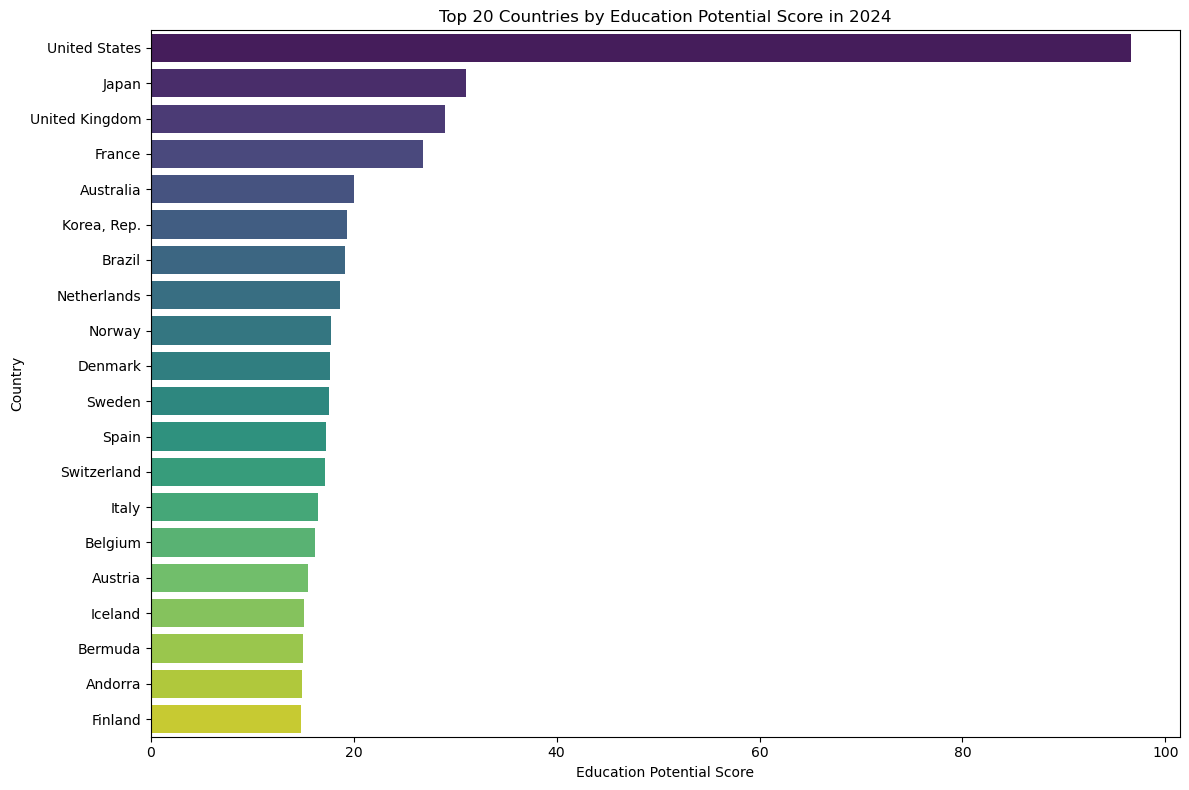

In [56]:
# Find the last year for which scores are available
last_scored_year = reshaped_table['Year'].max()

print(f"Analyzing the last year for which scores are available: {last_scored_year}")

# Filter the table for the last scored year
last_year_data = reshaped_table[reshaped_table['Year'] == last_scored_year].copy()

# Sort by Education Potential Score and take the top 20
top_countries_last_year = last_year_data.sort_values(by='Education Potential Score', ascending=False).head(20)

# Display the top 20 countries for the last scored year
print(f"\nTop 20 Countries by Education Potential Score in {last_scored_year}:")
display(top_countries_last_year)

# Create a bar graph for the top 20 countries in the last scored year
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Education Potential Score',
    y='Country Name',
    data=top_countries_last_year,
    palette='viridis' # Using 'viridis' palette for a color gradient
)

plt.title(f'Top 20 Countries by Education Potential Score in {last_scored_year}')
plt.xlabel('Education Potential Score')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

C:\Users\shahu\AppData\Local\Temp\ipykernel_26744\617851980.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


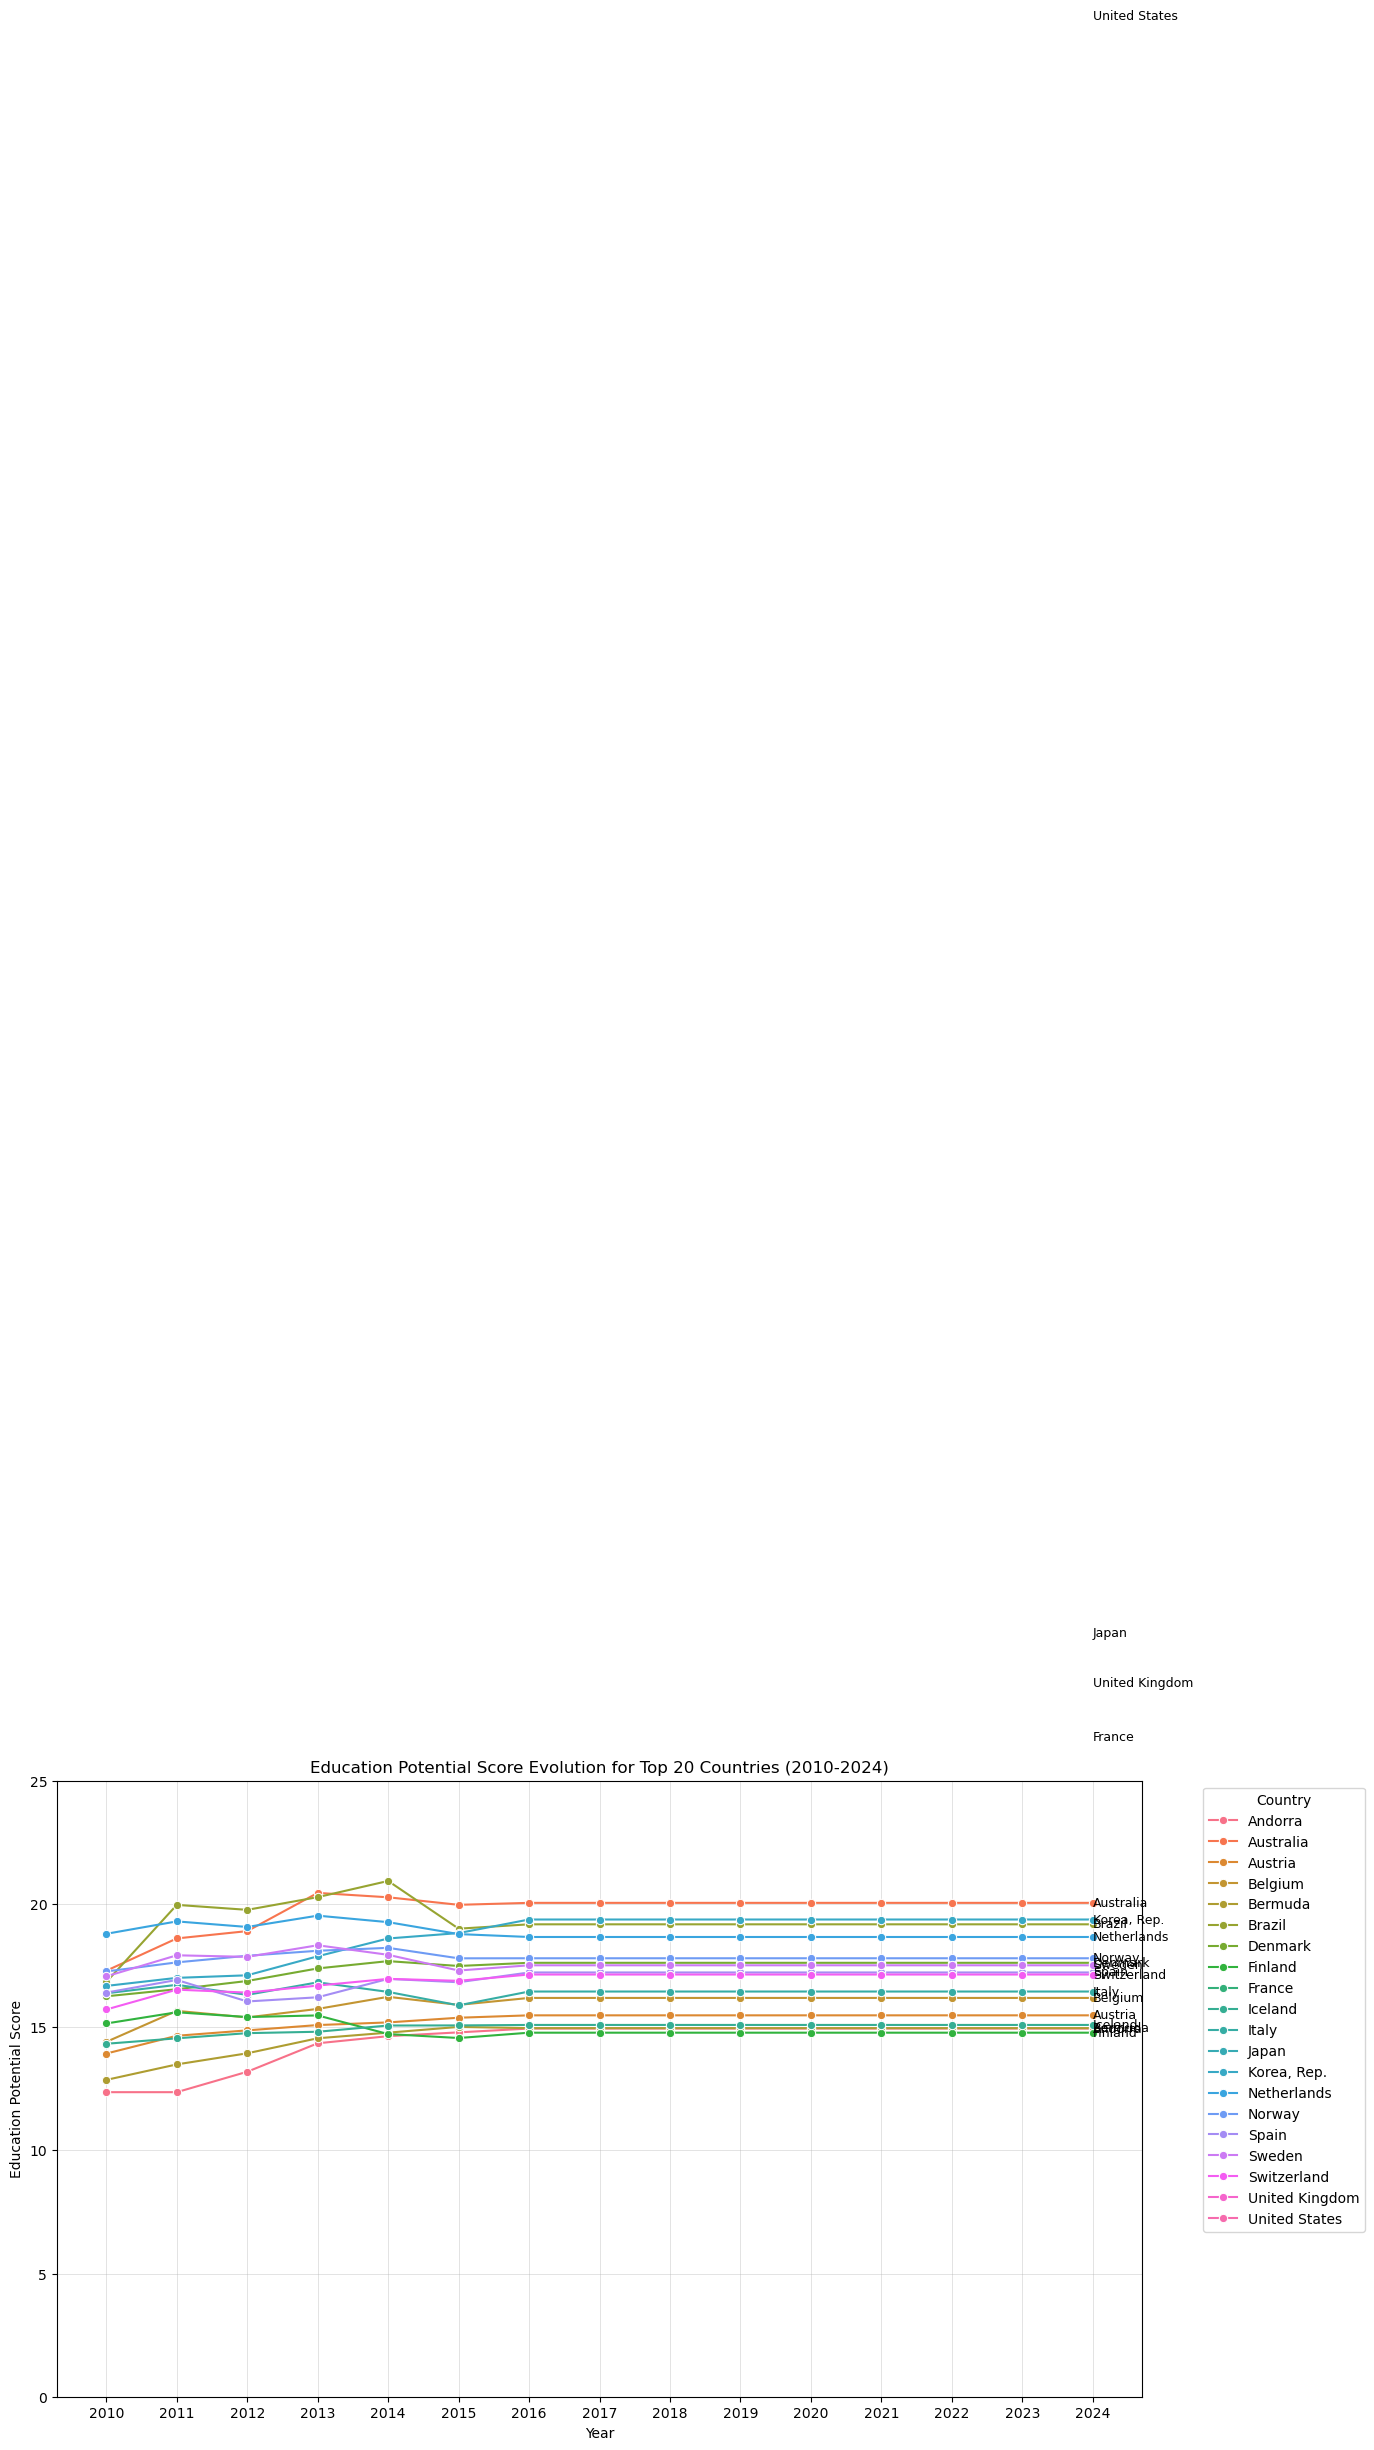

In [57]:
# Filter for the top 20 countries based on the last available year's score
top_20_country_codes = top_countries_last_year['Country Code'].tolist()
top_countries_over_time = reshaped_table[reshaped_table['Country Code'].isin(top_20_country_codes)].copy()

# Create a line plot for the top 20 countries over time
plt.figure(figsize=(14, 8))
ax = sns.lineplot(
    data=top_countries_over_time,
    x='Year',
    y='Education Potential Score',
    hue='Country Name', # Use 'Country Name' to differentiate lines by country
    marker='o' # Add markers to the data points
)

# Add country names as labels on the lines (at the last data point)
for country in top_20_country_codes:
    country_data = top_countries_over_time[top_countries_over_time['Country Code'] == country]
    last_year_data = country_data[country_data['Year'] == country_data['Year'].max()]
    if not last_year_data.empty:
        x = last_year_data['Year'].iloc[0]
        y = last_year_data['Education Potential Score'].iloc[0]
        country_name = last_year_data['Country Name'].iloc[0]
        ax.text(x, y, country_name, fontsize=9, ha='left', va='center')

plt.title('Education Potential Score Evolution for Top 20 Countries (2010-2024)')
plt.xlabel('Year')
plt.ylabel('Education Potential Score')
plt.ylim(0, 25) # Enlarge the y-axis from 0 to 25
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside the plot
plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.5) # Make the grid lines smaller and less prominent
plt.tight_layout()
plt.show()

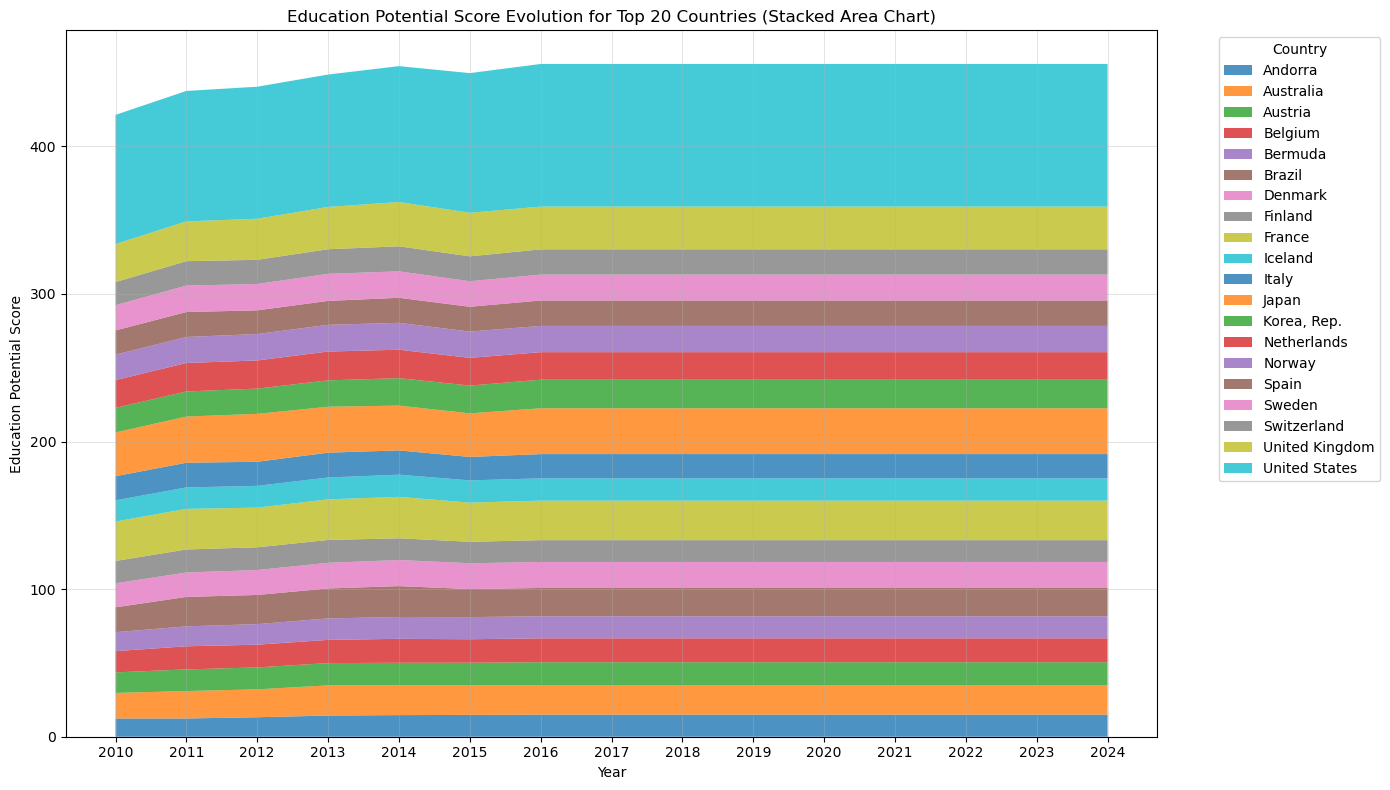

In [58]:
# Filter for the top 20 countries based on the last available year's score
top_20_country_codes = top_countries_last_year['Country Code'].tolist()
top_countries_over_time = reshaped_table[reshaped_table['Country Code'].isin(top_20_country_codes)].copy()

# Create a stacked area chart for the top 20 countries over time
plt.figure(figsize=(14, 8))
plt.stackplot(
    top_countries_over_time.pivot(index='Year', columns='Country Name', values='Education Potential Score').index,
    top_countries_over_time.pivot(index='Year', columns='Country Name', values='Education Potential Score').T.values,
    labels=top_countries_over_time['Country Name'].unique(),
    alpha=0.8
)

plt.title('Education Potential Score Evolution for Top 20 Countries (Stacked Area Chart)')
plt.xlabel('Year')
plt.ylabel('Education Potential Score')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside the plot
plt.grid(True, linestyle='-', linewidth=0.5, alpha=0.5) # Make the grid lines smaller and less prominent
plt.tight_layout()
plt.show()

Extraction of texts and output